# **Preparation: Persona & Agent extrapolation**

## **1. CONFIG & HELPERS**
Edit the **CONFIG** cell to change paths, GFA, batch size, rents, and all knobs. All helper functions (including `run_scenario`) are in the **HELPERS** cell. Run both before the rest of the notebook.

In [26]:
# =============================================================================
# CONFIG — All variables in one place (edit here to test new numbers)
# =============================================================================
import os
import random
import math
from time import time
import pandas as pd
import numpy as np

# ----- 1. PATHS (change BASE_DIR to switch project folder) -----
BASE_DIR = "/Users/tumenglun/Desktop/ABM"
PERSONAS_CSV   = os.path.join(BASE_DIR, "personas_downtown_boston-1.csv")
OUT_CSV        = os.path.join(BASE_DIR, "agents_mixture.csv")
agent_csv      = os.path.join(BASE_DIR, "agents_mixture.csv")
AGENT_CSV_PATH = agent_csv
OUT_DIR        = BASE_DIR
CSV_PATH       = agent_csv   # for Phase 01 verification

# ----- 2. AGENT GENERATION (Preparation) -----
N_AGENTS    = 3000
SEED        = 93
TAU_PERSONA = 100.0   # higher → more blending; lower → closer to single personas

# ----- 3. PHASE 01 — Optional verification (size eligibility) -----
PAD_PCT = 0.15   # ±15% padding around each unit type's avg size
PAD_SF  = None   # or set e.g. 120.0 for absolute ±sf

# ----- 4. SIMULATION BASE -----
total_GFA       = 45900
unit_type_list  = ["studio", "1BR", "2BR"]
batch_size      = 40
time_unit       = "month"
target_occ      = 0.90
max_batches     = 200
n_scenarios     = 500
TOP_Q           = 0.50   # start rent from top of range (0.5 = median band)
review_every    = 1
RNG_SEED        = 42

# ----- 5. SIZE & RENT RANGES (Boston downtown calibrated) -----
size_range = {
    "studio": (460, 580),
    "1BR":    (640, 820),
    "2BR":    (850, 1000),
    "3BR":    (1150, 1450),
}
AVG_SIZE = {k: 0.5 * (lo + hi) for k, (lo, hi) in size_range.items()}
rent_sf_range = {
    "studio": (5.5, 6.1),
    "1BR":    (5.3, 6.0),
    "2BR":    (4.9, 5.5),
    "3BR":    (5.2, 5.5),
}
mix_prior_alpha = np.ones(len(unit_type_list))   # uniform mix; tweak to bias

# ----- 6. UTILITY & RENT KNOBS -----
K             = 5    # Top-K results
TAU           = 0.35   # softmax temperature in run_scenario (sharper choices)
TAU_CHOICE    = 0.05   # softmax temperature for choice (higher = more dithering)
WAIT_BIAS     = 0.40   # raises utility of "wait" => slower absorption
SIGMA_DEFAULT = (0.15, 0.25)   # price tolerance band (fraction of WTP)
ALPHA_LNG     = 1.0
G_CAP         = 0.8
BLEND         = 0
B_SIZE        = 0.70
B_BED         = 0.90
B_CULT        = 0.50
TYPE_ALPHA    = {"studio": 0.15, "1BR": 0.25, "2BR": 0.85, "3BR": 0.5}
RENT_STEP       = 0.03
RENT_UP_CAP     = 0.05
RENT_DOWN_CAP   = 0.07
RENT_SMOOTH_EMA = 0.80
MIN_UNIT_COUNTS = {"studio": 10, "1BR": 10, "2BR": 10, "3BR": 0}
RELEASE_INIT  = 0.20
ADJ_STEP      = 0.25
TARGET_ABSORB = 0.70
ETA        = 0.10
ETA_BY_TYPE = {"studio": 0.45, "1BR": 0.55, "2BR": 0.45, "3BR": 0.25}
MIN_RENT   = {"studio": 2200, "1BR": 3000, "2BR": 4500, "3BR": 5500}
MAX_RENT   = {"studio": 3500, "1BR": 4500, "2BR": 6500, "3BR": 9000}
RENT_JITTER = 1.0
ETA_SCALE   = 1.0

# ----- 7. POST-FILTER (Phase 3.6) -----
TOTAL_GFA_CAP  = total_GFA
MIN_BADGE_REQ  = 6

# ----- 8. VISUALIZATION -----
Vis_K       = 20
K_REVENUE   = Vis_K
K_FASTEST   = Vis_K
AROUND_K    = Vis_K
TARGET_TIME = 15
# Toggle which Top-K sets to plot
VIS_PLOT_REVENUE = False
VIS_PLOT_FASTEST = False
VIS_PLOT_NEAR    = True
VIS_PLOT_GIF    = True   # animate rent & occupancy (G- and I-style) for enabled sets
os.makedirs("out", exist_ok=True)

# ----- Reproducibility -----
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

In [2]:
# === HELPERS — simulation (run CONFIG cell first) ===
import math
import numpy as np
import pandas as pd

def softmax_vec(vals, tau=TAU_CHOICE):
    vals = np.asarray(vals, dtype=float)
    if tau <= 0:
        y = np.zeros_like(vals)
        y[np.nanargmax(vals)] = 1.0
        return y
    z = vals / tau
    z -= np.nanmax(z)
    e = np.exp(z)
    s = np.nansum(e)
    return e / s if s > 0 else np.ones_like(vals) / len(vals)

def get_agent_sigma(agent_row):
    lo, hi = SIGMA_DEFAULT
    return np.random.uniform(lo, hi)

def gaussian_price_fit(wtp_monthly, price, sigma_frac):
    w = max(float(wtp_monthly), 1e-6)
    s = max(float(sigma_frac), 1e-6) * w
    z = (float(price) - w) / s
    return math.exp(-z*z)

def bed_mismatch_penalty(bed_need, unit_type):
    if unit_type == "studio":
        return 0.0 if bed_need <= 1 else 1.5
    if bed_need == 1 and unit_type in ("2BR", "3BR"):
        return 1.5
    if bed_need >= 2 and unit_type == "1BR":
        return 1.2
    return 0.0

def eligible(unit_type, agent_row):
    hh = int(agent_row.get("hh_size", 1))
    if unit_type.lower().startswith("studio") and hh >= 3:
        return False
    return True

def outside_utility(agent_row):
    hh = int(agent_row.get("hh_size", 1))
    base = -0.25 - 0.15 * max(hh - 1, 0)
    return base + WAIT_BIAS

def _largest_remainder_round(targets):
    floors = {k: int(np.floor(v)) for k, v in targets.items()}
    rem = int(round(sum(targets.values()) - sum(floors.values())))
    if rem <= 0:
        return floors
    fracs = sorted(((k, targets[k] - floors[k]) for k in targets), key=lambda x: x[1], reverse=True)
    for i in range(rem):
        floors[fracs[i % len(fracs)][0]] += 1
    return floors

def enforce_min_counts(unit_counts, min_counts, total_units=None, relax_when_infeasible=True):
    min_counts = min_counts or {}
    types = sorted(set(unit_counts.keys()) | {u for u, f in min_counts.items() if int(f) > 0})
    floors = {u: int(min_counts.get(u, 0)) for u in types}
    counts = {u: int(unit_counts.get(u, 0)) for u in types}
    if total_units is not None:
        floor_sum = sum(floors.values())
        if floor_sum > total_units:
            if not relax_when_infeasible:
                raise ValueError(f"Sum of minimums ({floor_sum}) exceeds total_units ({total_units}).")
            scale = total_units / float(floor_sum)
            targets = {u: floors[u] * scale for u in types}
            floors = _largest_remainder_round(targets)
    counts = {u: max(counts[u], floors[u]) for u in types}
    if total_units is None:
        return counts
    cur = sum(counts.values())
    if cur == total_units:
        return counts
    if cur < total_units:
        extras = total_units - cur
        headroom = {u: max(int(unit_counts.get(u, 0)) - floors[u], 0) for u in types}
        total_head = sum(headroom.values())
        if total_head == 0:
            targets = {u: counts[u] + extras / len(types) for u in types}
        else:
            targets = {u: counts[u] + extras * (headroom[u] / total_head) for u in types}
        return _largest_remainder_round(targets)
    over = cur - total_units
    surplus = {u: max(counts[u] - floors[u], 0) for u in types}
    total_surplus = sum(surplus.values())
    if total_surplus == 0:
        scale = total_units / max(sum(floors.values()), 1)
        targets = {u: floors[u] * scale for u in types}
        return _largest_remainder_round(targets)
    targets = {u: counts[u] - over * (surplus[u] / total_surplus) for u in types}
    rounded = _largest_remainder_round(targets)
    for u in types:
        rounded[u] = max(rounded[u], floors[u])
    drift = total_units - sum(rounded.values())
    if drift != 0:
        pool = (types if drift > 0 else [u for u in types if rounded[u] > floors[u]])
        i = 0
        while drift != 0 and pool:
            u = pool[i % len(pool)]
            if drift > 0:
                rounded[u] += 1; drift -= 1
            else:
                if rounded[u] > floors[u]:
                    rounded[u] -= 1; drift += 1
            i += 1
    return rounded

def derive_total_units_row(row, typ):
    occ = row.get(f"occupied_{typ}", np.nan)
    val = row.get(f"units_{typ}", np.nan)
    if pd.notna(val):
        try:
            val_i = int(val)
            if pd.isna(occ) or val_i >= int(occ):
                return max(val_i, int(occ) if pd.notna(occ) else 0)
        except Exception:
            pass
    st, sa = row.get(f"sqft_total_{typ}", np.nan), row.get(f"sqft_{typ}", np.nan)
    if pd.notna(st) and pd.notna(sa):
        try:
            sa_f = float(sa)
            if sa_f > 0:
                est = int(max(1, round(float(st) / sa_f)))
                return max(est, int(occ) if pd.notna(occ) else 0)
        except Exception:
            pass
    comp = bool(row.get("completed", False))
    hitl = bool(row.get("hit_limit", False))
    ttf  = row.get("time_to_fill", np.inf)
    ok_t = True if "max_batches" not in globals() else (pd.notna(ttf) and ttf < max_batches)
    if comp and (not hitl) and ok_t and pd.notna(occ):
        return int(occ)
    return int(occ) if pd.notna(occ) else np.nan

# ----- Scenario generation (used by "Generate Scenarios" cell) -----
def sample_unit_mix(unit_types, alpha_vec):
    shares = np.random.dirichlet(alpha_vec)
    return {u: float(s) for u, s in zip(unit_types, shares)}

def sample_avg_sizes(unit_types, size_rng):
    return {u: float(np.random.uniform(*size_rng[u])) for u in unit_types}

def counts_from_gfa(total_gfa, mix, avg_size):
    counts = {u: int((total_gfa * mix[u]) // avg_size[u]) for u in mix.keys()}
    used = sum(counts[u] * avg_size[u] for u in mix.keys())
    leftover = total_gfa - used
    while True:
        candidates = [(u, avg_size[u]) for u in mix.keys() if avg_size[u] <= leftover]
        if not candidates:
            break
        u_add = max(candidates, key=lambda t: t[1])[0]
        counts[u_add] += 1
        leftover -= avg_size[u_add]
    return counts

def gen_scenarios(n_scenarios, total_gfa, unit_types, size_rng, rent_sf_rng, mix_alpha):
    scenarios = []
    for i in range(n_scenarios):
        avg_size_i = sample_avg_sizes(unit_types, size_rng)
        mix_i = sample_unit_mix(unit_types, mix_alpha)
        counts_i = counts_from_gfa(total_gfa, mix_i, avg_size_i)
        total_units_i = int(sum(counts_i.values()))
        if total_units_i == 0:
            avg_size_i = {u: size_rng[u][0] for u in unit_types}
            eq = 1.0 / len(unit_types)
            mix_i = {u: eq for u in unit_types}
            counts_i = counts_from_gfa(total_gfa, mix_i, avg_size_i)
            total_units_i = int(sum(counts_i.values()))
        rent_per_sf_i = {}
        for u in unit_types:
            lo, hi = rent_sf_rng[u]
            lo_q = lo + (1.0 - TOP_Q) * (hi - lo)
            rent_per_sf_i[u] = float(np.random.uniform(lo_q, hi))
        rent_i = {u: avg_size_i[u] * rent_per_sf_i[u] for u in unit_types}
        scenarios.append({
            "id": f"S{i+1:02d}",
            "unit_types": unit_types[:],
            "avg_size": avg_size_i,
            "mix": mix_i,
            "unit_counts": counts_i,
            "total_units": total_units_i,
            "rent_per_sf": rent_per_sf_i,
            "rent": rent_i
        })
    return scenarios

In [3]:
# --- Build Dirichlet alphas from persona shares (uses CONFIG: PERSONAS_CSV, N_AGENTS, OUT_CSV, SEED, TAU_PERSONA) ---
import pandas as pd
dfp = pd.read_csv(PERSONAS_CSV)
shares = dfp["share"] / dfp["share"].sum()
dirichlet_alpha = (shares * TAU_PERSONA).tolist()

# --- Optional: persona-specific rent-burden ranges (housing ratio) ---
# Example: nudge one persona tighter affordability while leaving others default (0.25–0.33)
housing_ratio_ranges_by_persona = {name: (0.25, 0.33) for name in dfp["name"]}
# housing_ratio_ranges_by_persona["grad_student_intl"] = (0.28, 0.36)

# --- Run ---
from agent_generator import generate_agents_from_csv
df_agents = generate_agents_from_csv(
    personas_csv=PERSONAS_CSV,
    n_agents=N_AGENTS,
    use_mixture_personas=True,
    dirichlet_alpha=dirichlet_alpha,
    housing_ratio_ranges_by_persona=housing_ratio_ranges_by_persona,
    seed=SEED
)

display(df_agents.head(10))
print(len(df_agents), "agents")
df_agents.to_csv(OUT_CSV, index=False)


,agent_id,persona_base,persona_mixture,income_monthly,housing_ratio,wtp_monthly,bed_need,sf_pref_low,sf_pref_high,floor_pref,noise_tol,elasticity,cultural_fit,availability_month,style_words,amenity_rank
0,A0001,young_pro,"{'young_pro': 0.318, 'grad_student_intl': 0.24...",10212.0,0.295,2971,1,470,595,med,low,0.82,0.57,5,"[warm_wood, modern_lux, minimal]","[concierge, wifi, laundry]"
1,A0002,young_pro,"{'young_pro': 0.314, 'grad_student_intl': 0.17...",9810.0,0.251,2481,2,497,702,high,low,0.99,0.57,4,"[minimal, modern_lux, warm_wood]","[gym, wifi, quiet_zone]"
2,A0003,young_pro,"{'young_pro': 0.295, 'grad_student_intl': 0.26...",8234.0,0.329,2810,2,527,769,med,med,0.96,0.57,1,"[minimal, warm_wood, modern_lux]","[laundry, laundry_shared, elevator_proximity]"
3,A0004,young_pro,"{'young_pro': 0.309, 'grad_student_intl': 0.28...",9037.0,0.298,2576,1,383,559,low,med,0.97,0.69,3,"[minimal, calm_tone, soft_brightness]","[package_room, roof_deck, study_lounge]"
4,A0005,grad_student_intl,"{'young_pro': 0.265, 'grad_student_intl': 0.27...",9601.0,0.281,2615,0,534,723,med,low,0.91,0.57,3,"[task_lighting, classic, warm_wood]","[bike_storage, laundry, roof_deck]"
5,A0006,young_pro,"{'young_pro': 0.315, 'grad_student_intl': 0.19...",8284.0,0.265,2297,1,557,729,med,med,1.10,0.37,1,"[matte_black, minimal, warm_wood]","[package_room, roof_deck, gym]"
6,A0007,young_pro,"{'young_pro': 0.325, 'grad_student_intl': 0.15...",8926.0,0.330,3064,1,561,790,med,med,1.05,0.65,1,"[matte_black, minimal, calm]","[laundry_shared, 24hr_access, concierge]"
7,A0008,grad_student_intl,"{'young_pro': 0.263, 'grad_student_intl': 0.29...",7234.0,0.317,2408,2,534,715,low,high,0.88,0.55,1,"[soft_light, classic, non_slip]","[study_lounge, 24hr_access, roof_deck]"
8,A0009,young_pro,"{'young_pro': 0.261, 'grad_student_intl': 0.25...",7870.0,0.326,2533,2,381,579,high,med,1.14,0.56,4,"[non_slip, matte_black, classic]","[roof_deck, 24hr_access, gym]"
9,A0010,young_pro,"{'young_pro': 0.406, 'grad_student_intl': 0.18...",9792.0,0.256,2580,1,398,603,med,low,1.03,0.61,5,"[art_display, matte_black, task_lighting]","[in_unit_laundry, roof_deck, package_room]"


3000 agents


Loaded 3000 agents
Saved diagnostics → /Users/tumenglun/Desktop/ABM/candidate_distribution_diagnostics.csv
unit_type  avg_size  window_covers_% (no pad)  eligible_% (with pad)  eligible_count
   studio     520.0                      40.7                   53.4            1602
      1BR     730.0                      46.3                   88.6            2658
      2BR     925.0                       1.8                   25.6             768
      3BR    1300.0                       0.0                    0.0               0
Saved summary → /Users/tumenglun/Desktop/ABM/candidate_distribution_summary.csv
Saved breakdowns → /Users/tumenglun/Desktop/ABM/candidate_distribution_breakdowns.csv


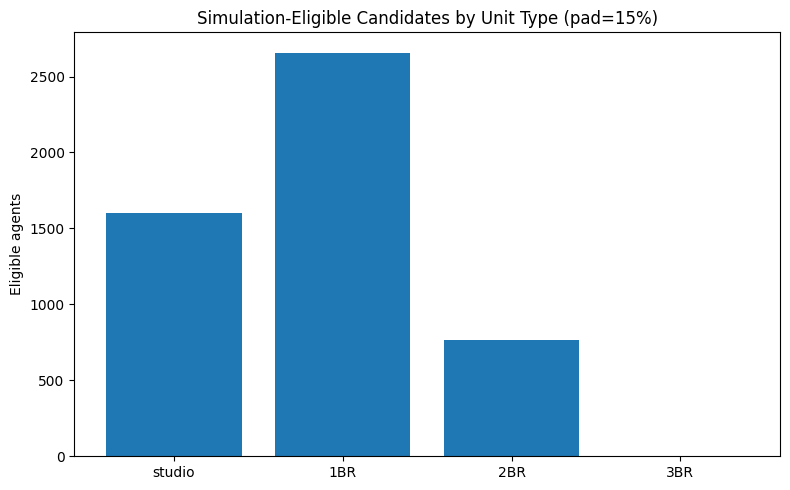

Saved plot → /Users/tumenglun/Desktop/ABM/candidate_distribution_plot.png


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
# Uses CONFIG: CSV_PATH, OUT_DIR, AVG_SIZE, PAD_PCT, PAD_SF
os.makedirs(OUT_DIR, exist_ok=True)

# --- Load agents ---
agents = pd.read_csv(CSV_PATH)
N = len(agents)
print(f"Loaded {N} agents")

# --- Ensure required columns (and numeric types) ---
def ensure_numeric(df, col, default=None, dtype=float):
    if col not in df.columns:
        df[col] = default
    df[col] = pd.to_numeric(df[col], errors="coerce")
    if default is not None:
        df[col] = df[col].fillna(default)
    return df[col].astype(dtype) if dtype is int else df[col]

if "agent_id" not in agents.columns:
    agents["agent_id"] = np.arange(N) + 1

ensure_numeric(agents, "bed_need", default=1, dtype=int)
ensure_numeric(agents, "hh_size",  default=1, dtype=int)

# Bounds: blanks/NaN => unbounded
agents["sf_pref_low"]  = pd.to_numeric(agents.get("sf_pref_low",  np.nan), errors="coerce")
agents["sf_pref_high"] = pd.to_numeric(agents.get("sf_pref_high", np.nan), errors="coerce")
sf_lo = agents["sf_pref_low"].fillna(-np.inf).to_numpy()
sf_hi = agents["sf_pref_high"].fillna(+np.inf).to_numpy()
bed   = agents["bed_need"].to_numpy()

UNIT_TYPES = list(AVG_SIZE.keys())

def padded_size_ok(sf, lo_arr, hi_arr, pad_pct=None, pad_sf=None):
    """
    Vectorized padded size check:
      (lo - pad) <= sf <= (hi + pad)
    pad can be specified by pad_pct (fraction of sf) or pad_sf (absolute).
    """
    if pad_pct is not None:
        pad = pad_pct * sf
    elif pad_sf is not None:
        pad = float(pad_sf)
    else:
        pad = 0.0
    return (lo_arr - pad <= sf) & (sf <= hi_arr + pad)

# --- Build eligibility masks per unit type (vectorized) ---
masks = {}
diag_rows = []
for u in UNIT_TYPES:
    sf = float(AVG_SIZE[u])

    # size coverage (un-padded) for diagnostics
    size_window_covers = (sf_lo <= sf) & (sf <= sf_hi)

    # eligibility with padding
    size_ok = padded_size_ok(sf, sf_lo, sf_hi, pad_pct=PAD_PCT, pad_sf=PAD_SF)

    if u == "studio":
        bed_ok = (bed <= 1)  # studios blocked if bed_need > 1
    else:
        bed_ok = np.ones_like(size_ok, dtype=bool)

    eligible_mask = size_ok & bed_ok
    masks[u] = eligible_mask

    # Diagnostics row
    diag_rows.append({
        "unit_type": u,
        "avg_size": sf,
        "window_covers_% (no pad)": round(100.0 * size_window_covers.sum() / N, 1),
        "eligible_% (with pad)":    round(100.0 * eligible_mask.sum() / N, 1),
        "eligible_count": int(eligible_mask.sum()),
    })

# --- Save diagnostics ---
diag = pd.DataFrame(diag_rows)
diag_path = os.path.join(OUT_DIR, "candidate_distribution_diagnostics.csv")
diag.to_csv(diag_path, index=False)
print(f"Saved diagnostics → {diag_path}")
print(diag.to_string(index=False))

# --- Summary ---
summary = pd.DataFrame(
    [{"unit_type": u,
      "eligible_count": int(masks[u].sum()),
      "eligible_percent": round(100.0 * masks[u].sum() / N, 1)} for u in UNIT_TYPES]
)
summary_path = os.path.join(OUT_DIR, "candidate_distribution_summary.csv")
summary.to_csv(summary_path, index=False)
print(f"Saved summary → {summary_path}")

# --- Breakdowns (by hh_size and bed_need) ---
def breakdown(mask, by_col, unit_type):
    subset = agents.loc[mask, [by_col]].copy()
    if subset.empty:
        return pd.DataFrame(columns=[by_col, "count", "percent", "unit_type"])
    g = subset.groupby(by_col, dropna=False).size().reset_index(name="count")
    g["percent"] = (100.0 * g["count"] / g["count"].sum()).round(1)
    g["unit_type"] = unit_type
    return g[[by_col, "count", "percent", "unit_type"]]

breakdowns = []
for u in UNIT_TYPES:
    breakdowns.append(breakdown(masks[u], "hh_size", u))
    breakdowns.append(breakdown(masks[u], "bed_need", u))
breakdowns_df = pd.concat(breakdowns, ignore_index=True)
breakdowns_path = os.path.join(OUT_DIR, "candidate_distribution_breakdowns.csv")
breakdowns_df.to_csv(breakdowns_path, index=False)
print(f"Saved breakdowns → {breakdowns_path}")

# --- Plot ---
x = np.arange(len(UNIT_TYPES))
vals = [int(masks[u].sum()) for u in UNIT_TYPES]
plt.figure(figsize=(8,5))
plt.bar(x, vals)
plt.xticks(x, UNIT_TYPES)
plt.ylabel("Eligible agents")
plt.title(f"Simulation-Eligible Candidates by Unit Type (pad={'{:.0%}'.format(PAD_PCT) if PAD_PCT is not None else (str(PAD_SF)+' sf' if PAD_SF is not None else 'none')})")
plt.tight_layout()
plot_path = os.path.join(OUT_DIR, "candidate_distribution_plot.png")
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Saved plot → {plot_path}")


# **Phase 01: Agent Varification** *(Optional)*

In [5]:
# PHASE 1 — setup
import pandas as pd
import numpy as np

# --- USER SETTINGS ---
AGENT_CSV_PATH = "/Users/tumenglun/Desktop/DRE/agents_mixture.csv"

In [6]:
# read the csv
df_agents = pd.read_csv(AGENT_CSV_PATH)

# quick checks
print(f"Loaded {len(df_agents)} agents")
display(df_agents.head())
display(df_agents.info())


Loaded 3000 agents


,agent_id,persona_base,persona_mixture,income_monthly,housing_ratio,wtp_monthly,bed_need,sf_pref_low,sf_pref_high,floor_pref,noise_tol,elasticity,cultural_fit,availability_month,style_words,amenity_rank
0,A0001,young_pro,"{'young_pro': 0.318, 'grad_student_intl': 0.24...",10212.0,0.295,2971,1,470,595,high,med,0.82,0.57,5,"['modern_lux', 'soft_light', 'warm_wood']","['concierge', 'quiet_zone', 'gym']"
1,A0002,young_pro,"{'young_pro': 0.314, 'grad_student_intl': 0.17...",9810.0,0.251,2481,2,497,702,low,med,0.99,0.57,4,"['warm_wood', 'soft_light', 'non_slip']","['roof_deck', 'quiet_zone', '24hr_access']"
2,A0003,young_pro,"{'young_pro': 0.295, 'grad_student_intl': 0.26...",8234.0,0.329,2810,2,527,769,high,med,0.96,0.57,1,"['warm_wood', 'matte_black', 'minimal']","['gym', 'laundry_shared', 'community_room']"
3,A0004,young_pro,"{'young_pro': 0.309, 'grad_student_intl': 0.28...",9037.0,0.298,2576,1,383,559,med,high,0.97,0.69,3,"['minimal', 'soft_light', 'non_slip']","['study_lounge', 'gym', 'package_room']"
4,A0005,grad_student_intl,"{'young_pro': 0.265, 'grad_student_intl': 0.27...",7687.0,0.283,2231,1,541,703,high,med,0.83,0.57,3,"['art_display', 'warm_wood', 'compact']","['laundry', 'gym', 'quiet_zone']"


<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   agent_id            3000 non-null   str    
 1   persona_base        3000 non-null   str    
 2   persona_mixture     3000 non-null   str    
 3   income_monthly      3000 non-null   float64
 4   housing_ratio       3000 non-null   float64
 5   wtp_monthly         3000 non-null   int64  
 6   bed_need            3000 non-null   int64  
 7   sf_pref_low         3000 non-null   int64  
 8   sf_pref_high        3000 non-null   int64  
 9   floor_pref          3000 non-null   str    
 10  noise_tol           3000 non-null   str    
 11  elasticity          3000 non-null   float64
 12  cultural_fit        3000 non-null   float64
 13  availability_month  3000 non-null   int64  
 14  style_words         3000 non-null   str    
 15  amenity_rank        3000 non-null   str    
dtypes: float64(4), in

None

# **Phase 02: Design Parameters**

**A: Simulation Base Settings**

In [7]:
# All simulation knobs and seeds are in the CONFIG cell. Run CONFIG first.



**B: Load Agents**

In [8]:
# PHASE 2 | Load agents
use_cols = [
    "agent_id","persona_base","persona_mixture","income_monthly","housing_ratio",
    "wtp_monthly","bed_need","sf_pref_low","sf_pref_high","floor_pref","noise_tol",
    "elasticity","cultural_fit","availability_month","style_words","amenity_rank"
]
df_agents = pd.read_csv(agent_csv, usecols=use_cols)

# required fields for the demo
req = ["agent_id","wtp_monthly","bed_need","sf_pref_low","sf_pref_high","availability_month","elasticity","cultural_fit"]
missing = [c for c in req if c not in df_agents.columns]
if missing:
    raise ValueError(f"Agent CSV missing required columns: {missing}")

# types
num_cols = [
    "income_monthly","housing_ratio","wtp_monthly","bed_need",
    "sf_pref_low","sf_pref_high","elasticity","cultural_fit","availability_month"
]
for c in num_cols:
    if c in df_agents.columns:
        df_agents[c] = pd.to_numeric(df_agents[c], errors="coerce")

df_agents = df_agents.dropna(subset=["wtp_monthly","bed_need","sf_pref_low","sf_pref_high","availability_month","elasticity","cultural_fit"]).copy()
df_agents["agent_id"] = df_agents["agent_id"].astype(str)

print(f"Loaded {len(df_agents)} agents.")
display(df_agents.head())

Loaded 3000 agents.


,agent_id,persona_base,persona_mixture,income_monthly,housing_ratio,wtp_monthly,bed_need,sf_pref_low,sf_pref_high,floor_pref,noise_tol,elasticity,cultural_fit,availability_month,style_words,amenity_rank
0,A0001,young_pro,"{'young_pro': 0.318, 'grad_student_intl': 0.24...",10212.0,0.295,2971,1,470,595,med,low,0.82,0.57,5,"['warm_wood', 'modern_lux', 'minimal']","['concierge', 'wifi', 'laundry']"
1,A0002,young_pro,"{'young_pro': 0.314, 'grad_student_intl': 0.17...",9810.0,0.251,2481,2,497,702,high,low,0.99,0.57,4,"['minimal', 'modern_lux', 'warm_wood']","['gym', 'wifi', 'quiet_zone']"
2,A0003,young_pro,"{'young_pro': 0.295, 'grad_student_intl': 0.26...",8234.0,0.329,2810,2,527,769,med,med,0.96,0.57,1,"['minimal', 'warm_wood', 'modern_lux']","['laundry', 'laundry_shared', 'elevator_proxim..."
3,A0004,young_pro,"{'young_pro': 0.309, 'grad_student_intl': 0.28...",9037.0,0.298,2576,1,383,559,low,med,0.97,0.69,3,"['minimal', 'calm_tone', 'soft_brightness']","['package_room', 'roof_deck', 'study_lounge']"
4,A0005,grad_student_intl,"{'young_pro': 0.265, 'grad_student_intl': 0.27...",9601.0,0.281,2615,0,534,723,med,low,0.91,0.57,3,"['task_lighting', 'classic', 'warm_wood']","['bike_storage', 'laundry', 'roof_deck']"


**C: Generate Scenarios**

In [9]:
# PHASE 2 | Generate scenarios (sample_unit_mix, counts_from_gfa, gen_scenarios are in HELPERS cell)
scenarios = gen_scenarios(
    n_scenarios=n_scenarios,
    total_gfa=total_GFA,
    unit_types=unit_type_list,
    size_rng=size_range,
    rent_sf_rng=rent_sf_range,
    mix_alpha=mix_prior_alpha
)

# Quick preview
preview = pd.DataFrame([{
    "scenario": s["id"],
    **{f"mix_{u}": round(s["mix"][u], 2) for u in unit_type_list},
    **{f"avg_size_{u}": round(s["avg_size"][u]) for u in unit_type_list},
    **{f"units_{u}": s["unit_counts"][u] for u in unit_type_list},
    "total_units": s["total_units"],
    **{f"rent_{u}": round(s["rent"][u]) for u in unit_type_list},
} for s in scenarios])
display(preview.head(10))

,scenario,mix_studio,mix_1BR,mix_2BR,avg_size_studio,avg_size_1BR,avg_size_2BR,units_studio,units_1BR,units_2BR,total_units,rent_studio,rent_1BR,rent_2BR
0,S01,0.46,0.47,0.07,516,761,950,40,28,4,72,3011,4546,5043
1,S02,0.35,0.24,0.41,559,685,906,28,16,21,65,3340,3988,4865
2,S03,0.44,0.07,0.49,498,674,889,40,5,25,70,2988,3991,4639
3,S04,0.20,0.35,0.45,560,796,879,16,21,23,60,3398,4549,4654
4,S05,0.55,0.01,0.44,566,731,966,45,0,21,66,3394,4341,5070
5,S06,0.18,0.34,0.48,579,741,957,14,21,23,58,3449,4216,5131
6,S07,0.07,0.91,0.02,564,641,851,6,65,1,72,3273,3801,4497
7,S08,0.72,0.26,0.03,526,669,854,62,17,2,81,3168,3791,4501
8,S09,0.15,0.81,0.04,497,713,897,14,52,2,68,2894,4121,4823
9,S10,0.51,0.08,0.42,490,736,854,47,4,23,74,2901,4233,4492


**D: Helpers & Variables**

In [10]:
# All simulation knobs and helper functions (softmax_vec, enforce_min_counts, run_scenario, etc.) are in CONFIG and HELPERS cells at the top.


**E: Single Simulation Run**

In [11]:
def run_scenario(scenario, agents_df, batch_size, target_occ, max_batches, review_every):
    import numpy as np
    import pandas as pd
    import os
    from time import time

    rng = np.random.default_rng(RNG_SEED if "RNG_SEED" in globals() else 42)
    review_offset = rng.integers(0, review_every)

    # --- pull scenario ---
    scenario_id = scenario.get("id", "NA")
    # --- scenario-level rent speed multiplier ---
    speed_key  = f"speed::{scenario_id}"
    speed_seed = abs(hash(speed_key)) % (2**32)
    RENT_SPEED = float(np.random.default_rng(speed_seed).normal(1.0, 0.60)) #(mean, sd)
    RENT_SPEED = max(0.3, min(RENT_SPEED, 2.0))  # clamp for stability


    unit_types   = scenario["unit_types"]
    unit_counts  = scenario["unit_counts"].copy()   # capacity per type
    avg_size     = scenario["avg_size"]             # sf per type
    rent_per_sf  = scenario["rent_per_sf"].copy()
    # apply mild rent jitter (±2%)
    for u in rent_per_sf:
        rent_per_sf[u] *= RENT_JITTER
    rent = {u: avg_size[u] * rent_per_sf[u] for u in unit_types}
    #total_units  = scenario["total_units"]
    unit_counts  = scenario["unit_counts"].copy()
    total_units  = scenario["total_units"]

    # Enforce floors last (after any other re-mix you do)
    unit_counts = enforce_min_counts(
        unit_counts=unit_counts,
        min_counts=MIN_UNIT_COUNTS,       # e.g., {'studio':3,'1BR':3,'2BR':3,'3BR':3}
        total_units=total_units,
        relax_when_infeasible=True
    )
    total_units = sum(unit_counts.values())   # keep in sync
    unit_types  = sorted(unit_counts.keys())  # use these from now on

    # --- per-scenario, per-type ETA jitter (breaks early parallel lines) ---
    scenario_eta_scale = {}
    for u in unit_types:
        # deterministic but different per (scenario_id, unit_type)
        key = f"{scenario_id}-{u}"
        seed = abs(hash(key)) % (2**32)
        local_rng = np.random.default_rng(seed)

        # strong spread so slopes really diverge from badge 1
        scale = local_rng.normal(loc=1.0, scale=0.40)   # <-- crank this for more/less divergence
        # keep within a sane band
        scale = max(0.3, min(scale, 1.8))  # clamp within [0.3, 1.8] for stability

        scenario_eta_scale[u] = scale

    # --- state ---
    occupied = {u: 0 for u in unit_types}  # leased count per type
    accepted_records = []
    rent_history, occ_history = [], []
    revenue = 0.0
    accepted_agent_ids = set()
    demand_accum = {u: 0.0 for u in unit_types}     # expected demand accumulator (per review window)

    # NEW: badge log (one row per unit_type per badge)
    badge_log = []

    def update_rent(type_name, current_rent, demand_t, remaining_supply_t):
        
        # --- inputs & safety ---
        current = float(current_rent)
        if current <= 0.0:
            current = 1.0

        cap = max(float(remaining_supply_t), 1.0)
        dem = float(demand_t)

        # --- base demand gap (normalized): >0 = excess demand, <0 = surplus ---
        base_gap = (dem - cap) / cap

        # --- small random shock on the gap to kill parallel lines early ---
        # use global _rng if it exists; else fall back to numpy's default
        try:
            eps = float(rng.normal(0.0, 0.15))   # std=0.15 → strong divergence
        except NameError:
            eps = float(np.random.normal(0.0, 0.15))

        gap = base_gap + eps

        # --- base step sensitivity ---
        if 'ETA_BY_TYPE' in globals() and 'ETA' in globals():
            base_eta = float(ETA_BY_TYPE.get(type_name, ETA))
        else:
            base_eta = float(RENT_STEP)  # fallback

        # --- apply scenario-level speed multiplier ---
        eta = base_eta * RENT_SPEED


        # --- raw unconstrained change (percent) ---
        raw_delta = eta * gap * RENT_SPEED


        # --- cap the per-review change (percent) ---
        up_cap = float(RENT_UP_CAP)
        dn_cap = float(RENT_DOWN_CAP)

        if raw_delta >= 0.0:
            delta_pct = min(raw_delta, up_cap)
        else:
            delta_pct = max(raw_delta, -dn_cap)

        # --- target rent after capped change ---
        target = current * (1.0 + delta_pct)

        # --- smooth the move (EMA) ---
        alpha = float(RENT_SMOOTH_EMA)  # 0..1
        new_rent = (1.0 - alpha) * current + alpha * target

        # --- clamp to min/max bands ---
        lo = MIN_RENT.get(type_name, 0.0) if 'MIN_RENT' in globals() else 0.0
        hi = MAX_RENT.get(type_name, 1e9) if 'MAX_RENT' in globals() else 1e9

        return float(np.clip(new_rent, lo, hi))


    # ----- tiny helper: per-person effective rent if you split by HH size -----
    PAYERS_BY_TYPE = {"studio": 1, "1BR": 1, "2BR": 2, "3BR": 2}

    def effective_rent_share(u):
        """Per-person (per-agent) rent used in utility; revenue uses full rent."""
        return float(rent[u]) / max(PAYERS_BY_TYPE.get(u, 1), 1)

    # size fit score ~ [0, 1], 1 if inside window, drops if far
    def size_fit_score(sf, lo, hi):
        if lo == -np.inf and hi == np.inf:
            return 0.8  # mild default if no preference stated
        if lo <= sf <= hi:
            return 1.0
        # within 10% band -> mild penalty, beyond -> stronger
        band = 0.10 * max(1.0, hi - lo if np.isfinite(hi - lo) else sf)
        if (sf < lo and lo - sf <= band) or (sf > hi and sf - hi <= band):
            return 0.85
        return 0.7

    start = time()
    batches_run = 0
    
    # Track per-type release state
    released      = {u: int(RELEASE_INIT * unit_counts[u]) for u in unit_types}
    release_rate  = {u: RELEASE_INIT for u in unit_types}
    prev_occ      = {u: 0 for u in unit_types}  # occupancy from last batch



    for batch in range(1, max_batches + 1):
        batches_run = batch
            # === [ADAPTIVE RELEASE BLOCK] ===
        for u in unit_types:
            last_released   = released[u]
            last_occ        = prev_occ[u]
            occ_now         = occupied[u]
            newly_leased    = max(occ_now - last_occ, 0)
            capacity_open   = max(last_released - last_occ, 1)
            absorption_ratio = newly_leased / capacity_open

            # adjust release rate
            if absorption_ratio > TARGET_ABSORB:
                release_rate[u] *= (1 + ADJ_STEP)
            elif absorption_ratio < TARGET_ABSORB * 0.5:
                release_rate[u] *= (1 - ADJ_STEP)

            release_rate[u] = float(np.clip(release_rate[u], 0.02, 0.5))
            new_units = int(release_rate[u] * unit_counts[u])
            released[u] = min(released[u] + new_units, unit_counts[u])

            # remember for next iteration
            prev_occ[u] = occ_now
   
        # agents available by this month
        pool = agents_df.loc[agents_df["availability_month"] <= batch]
        if len(pool) == 0:
            occ_history.append(sum(occupied.values()) / total_units if total_units > 0 else 1.0)
            # NEW: still log empty-batch state per unit_type
            for u in unit_types:
                cap_u = unit_counts[u]
                occ_u = occupied[u]
                badge_log.append({
                    "scenario_id": scenario_id,
                    "badge": batch,
                    "unit_type": u,
                    "rent": rent[u],
                    "assigned": occ_u,
                    "capacity": cap_u,
                    "occupancy_rate": (occ_u / cap_u if cap_u else np.nan),
                    "expected_demand_window": demand_accum[u],
                })
            continue

        # sample WITH replacement (ongoing demand this month)
        idxs = rng.choice(len(pool), size=batch_size, replace=True)
        batch_agents = pool.iloc[idxs]
        #
        for _, ag in batch_agents.iterrows():
            aid = ag["agent_id"]
            if aid in accepted_agent_ids:
                continue

            # eligible types by hard gates (do not remove full types so we can "see" excess demand)
            # FIX: call the correct helper and use one variable name
            elig_types = [u for u in unit_types if eligible(u, ag)]
            if not elig_types:
                continue  # forced wait; contributes nothing to demand_accum

            # (compat alias only if later code refers to 'eligible_type')
            eligible_type = elig_types

            # build utilities for eligible types
            cult = (float(ag["cultural_fit"]) - 0.5) if "cultural_fit" in ag and pd.notna(ag["cultural_fit"]) else 0.0
            bed_need = int(ag["bed_need"]) if "bed_need" in ag else 1
            lo = float(ag["sf_pref_low"])  if "sf_pref_low"  in ag and pd.notna(ag["sf_pref_low"])  else -np.inf
            hi = float(ag["sf_pref_high"]) if "sf_pref_high" in ag and pd.notna(ag["sf_pref_high"]) else  np.inf
            wtp = float(ag["wtp_monthly"]) if "wtp_monthly" in ag else 0.0

            U = {}
            for u in elig_types:
                                # --- non-price parts (unchanged) ---
                size_term  = B_SIZE  * size_fit_score(avg_size[u], lo, hi)
                bed_term   = -B_BED  * bed_mismatch_penalty(bed_need, u)
                cult_term  = B_CULT  * cult
                alpha      = TYPE_ALPHA.get(u, 0.0)

                # household-based nudge (unchanged)
                hh = int(ag["hh_size"]) if "hh_size" in ag else 1
                if hh >= 2 and u in ("2BR", "3BR"):
                    alpha += 0.50
                if hh == 1 and u == "1BR":
                    alpha += 0.20

                # --- Gaussian price-fit around WTP (Option A) ---
                # compare agent WTP to per-person rent share for this type
                price_for_choice = effective_rent_share(u)
                sigma_i = get_agent_sigma(ag)
                G = gaussian_price_fit(wtp, price_for_choice, sigma_i)  # (0,1], peak at match
                G = min(G, G_CAP)
                price_fit_term = ALPHA_LNG * math.log(max(G, 1e-12))
                
                U_raw = alpha + size_term + cult_term + bed_term + price_fit_term
                U_CAP = U.get("wait", 0.0) + 1.0
                
                U[u] = U_raw if U_raw <= U_CAP else (BLEND*U_CAP + (1-BLEND)*U_raw)


                # if you insist on a tiny linear tilt, add: + 0.1 * (wtp - price_for_choice)
                #U[u] = alpha + size_term + bed_term + cult_term + price_fit_term


            # add outside option
            U["wait"] = U.get("wait", 0.0) + outside_utility(ag)

            # expected demand probs over elig_types + wait
            ordered = elig_types + ["wait"]
            probs_vec = softmax_vec([U[k] for k in ordered], tau=TAU)
            probs = dict(zip(ordered, probs_vec))

            # accumulate expected demand per type (for pricing step)
            for u in elig_types:
                demand_accum[u] += probs[u]

            # realized choice (sample) — only leases if capacity remains
            pick = rng.choice(len(ordered), p=probs_vec)
            choice = ordered[pick]
            if choice != "wait":
                u = choice
                if occupied[u] < released[u]:
                    occupied[u] += 1
                    accepted_agent_ids.add(aid)
                    accepted_records.append({
                        "agent_id": aid,
                        "unit_type": u,
                        "batch_filled": batch,
                        "rent_paid": rent[u],
                        "wtp_monthly": wtp,
                        "persona_base": ag.get("persona_base", None),
                        "persona_mixture": ag.get("persona_mixture", None),
                        "sf_pref_low": ag.get("sf_pref_low", None),
                        "sf_pref_high": ag.get("sf_pref_high", None),
                        "bed_need": ag.get("bed_need", None),
                        "floor_pref": ag.get("floor_pref", None),
                        "noise_tol": ag.get("noise_tol", None),
                        "elasticity": ag.get("elasticity", None),
                        "cultural_fit": ag.get("cultural_fit", None),
                        "availability_month": ag.get("availability_month", None),
                        "style_words": ag.get("style_words", None),
                        "amenity_rank": ag.get("amenity_rank", None),
                    })

        # monthly revenue (simple)
        revenue += sum(rent[u] * occupied[u] for u in unit_types)

        # history
        total_occ = sum(occupied.values()) / total_units if total_units > 0 else 1.0
        occ_history.append(total_occ)
        rent_history.append({u: rent[u] for u in unit_types})

        # NEW: append this badge state to the log
        for u in unit_types:
            cap_u = unit_counts[u]
            occ_u = occupied[u]
            badge_log.append({
                "scenario_id": scenario_id,
                "badge": batch,
                "unit_type": u,
                "rent": rent[u],
                "assigned": occ_u,
                "capacity": cap_u,
                "occupancy_rate": (occ_u / cap_u if cap_u else np.nan),
                "expected_demand_window": demand_accum[u],
                "released": released[u]
            })

        # pricing: every review window, update TOTAL rent per type from expected demand vs remaining supply
        if (batch - review_offset) % review_every == 0:
            for u in unit_types:
                remaining_supply = max(unit_counts[u] - occupied[u], 0)
                rent[u] = update_rent(u, rent[u], demand_accum[u], max(remaining_supply, 1))
            # gentle ordering guardrails (optional — remove after stabilization)
            if "studio" in rent and "1BR" in rent:
                rent["1BR"] = max(rent["1BR"], rent["studio"] + 75)
            if "1BR" in rent and "2BR" in rent:
                rent["2BR"] = max(rent["2BR"], rent["1BR"] + 75)
            if "2BR" in rent and "3BR" in rent:
                rent["3BR"] = max(rent["3BR"], rent["2BR"] + 75)
            # reset accumulator for next window
            demand_accum = {u: 0.0 for u in unit_types}

        if total_occ >= target_occ:
            break

    # compute elapsed after the loop
    elapsed = time() - start

    accepted_df = pd.DataFrame(accepted_records)

    # status flags
    final_occupancy = sum(occupied.values()) / total_units if total_units > 0 else 1.0
    completed = final_occupancy >= target_occ
    hit_limit = (batches_run == max_batches) and (not completed)

    # effective horizon for rates (completion batch if done, else max horizon)
    effective_batches = batches_run if completed else max_batches

    # optional: revenue rates
    units_leased = max(sum(occupied.values()), 1)
    revenue_per_batch = revenue / max(effective_batches, 1)
    revenue_per_unit  = revenue / units_leased

    final_rent_per_sf = {u: rent[u] / avg_size[u] for u in unit_types}

    # --- SAVE LOG ---
    log_df = pd.DataFrame(badge_log)
    os.makedirs("logs", exist_ok=True)
    log_path = f"logs/scenario_{scenario_id}_badges.csv"
    log_df.to_csv(log_path, index=False)

    sid = scenario.get("scenario_id", scenario.get("id", scenario.get("name", "S?")))

    return {
    "scenario_id": sid,
    "time_to_fill": batches_run,
    "total_revenue": revenue,
    "final_rent": rent,
    "occupied_by_type": occupied,
    "completed": completed,
    "hit_limit": hit_limit,
    "rent_history": rent_history,
    "occ_history": occ_history,
    "final_occupancy": (sum(occupied.values()) / total_units) if total_units else np.nan,

    # ---- NEW: offered (supply) truth ----
    "unit_counts_final": unit_counts.copy(),                            # per-type offered
    "avg_size": {u: float(avg_size[u]) for u in unit_types},            # per-type size used
    "total_units": int(sum(unit_counts.values())),                      # offered total
    "total_gfa_offered": float(sum(avg_size[u] * unit_counts[u]         # offered GFA
                                   for u in unit_types)),
    # (optional alias so Phase 3.5 can read either name)
    "total_gfa_used": float(sum(avg_size[u] * unit_counts[u]
                                for u in unit_types)),
}


**F:Populate Testing**

In [12]:
# PHASE 3 | Multi-path search (Top-K revenue = completed scenarios only)
import numpy as np
import pandas as pd

all_results = []
for sc in scenarios:
    res = run_scenario(sc, df_agents, batch_size, target_occ, max_batches, review_every)
    all_results.append(res)

# Union of unit types that actually appear in results
all_unit_types = sorted(
    set().union(*[set(r["final_rent"].keys()) for r in all_results]) |
    set().union(*[set(r["occupied_by_type"].keys()) for r in all_results])
)

# Build full results table
rows = []
for r in all_results:
    row = {
        "scenario_id": r["scenario_id"],
        "time_to_fill": r["time_to_fill"],
        "total_revenue": r["total_revenue"],
        "final_occupancy": r.get("final_occupancy", np.nan),
        "completed": bool(r.get("completed", False)),
        "hit_limit": bool(r.get("hit_limit", False)),
    }

    # ---- NEW: average rents over badge history (up to completion) ----
    rent_hist = r.get("rent_history", [])  # list[dict(unit_type -> rent)]
    if rent_hist:
        # Only average through the actual completion badge if completed
        badge_limit = r["time_to_fill"] if r.get("completed", False) else len(rent_hist)
        rent_hist = rent_hist[:badge_limit]

        sums, counts = {}, {}
        for d in rent_hist:
            for u, val in d.items():
                sums[u] = sums.get(u, 0.0) + float(val)
                counts[u] = counts.get(u, 0) + 1
        avg_rents = {u: (sums[u] / counts[u]) for u in sums.keys()}
    else:
        avg_rents = {}

    for u in all_unit_types:
        ar = avg_rents.get(u, np.nan)
        row[f"avg_rent_{u}"] = (round(float(ar), 2) if pd.notna(ar) else np.nan)
        row[f"occupied_{u}"] = int(r["occupied_by_type"].get(u, 0))

    rows.append(row)

results_table = (
    pd.DataFrame(rows)
      .sort_values(by=["completed", "time_to_fill", "total_revenue"], ascending=[False, True, False])
      .reset_index(drop=True)
)


display(results_table)

# ---------- TOP-K (completed only) ----------

completed_df = results_table[
    (results_table["completed"] == True) &
    (results_table["hit_limit"] == False) &
    (results_table["time_to_fill"] < max_batches)
].copy()

if completed_df.empty:
    print("No completed scenarios. Consider lowering target_occ or raising max_batches.")
else:
    topk_revenue = (
        completed_df.sort_values(by=["total_revenue", "time_to_fill"], ascending=[False, True])
                    .head(K)
                    .reset_index(drop=True)
    )
    print(f"Top-{K} by revenue (COMPLETED ONLY):")
    display(topk_revenue)


,scenario_id,time_to_fill,total_revenue,final_occupancy,completed,hit_limit,avg_rent_1BR,occupied_1BR,avg_rent_2BR,occupied_2BR,avg_rent_studio,occupied_studio
0,S173,5,7.213996e+05,0.904762,True,False,3857.20,4,4530.53,34,2790.35,19
1,S488,5,7.192650e+05,0.907407,True,False,3518.81,5,4989.70,34,2771.34,10
2,S314,5,7.192289e+05,0.913043,True,False,3750.56,4,4730.06,27,2579.90,32
3,S262,5,7.161947e+05,0.924242,True,False,3424.95,7,4748.81,28,2541.04,26
4,S22,5,7.143403e+05,0.903226,True,False,3668.01,4,4587.57,34,2597.20,18
...,...,...,...,...,...,...,...,...,...,...,...,...
495,S163,200,3.552123e+07,0.758621,False,True,3482.10,24,6476.72,10,3377.59,10
496,S34,200,3.548319e+07,0.745763,False,True,3506.73,24,6427.21,10,3405.57,10
497,S493,200,3.546316e+07,0.771930,False,True,3506.01,24,6460.56,10,3405.38,10
498,S47,200,3.498159e+07,0.767857,False,True,3511.73,23,6457.36,10,3408.36,10


Top-5 by revenue (COMPLETED ONLY):


,scenario_id,time_to_fill,total_revenue,final_occupancy,completed,hit_limit,avg_rent_1BR,occupied_1BR,avg_rent_2BR,occupied_2BR,avg_rent_studio,occupied_studio
0,S54,30,4.983415e+06,0.904762,True,False,3615.87,34,6327.50,10,3283.76,13
1,S477,28,4.285280e+06,0.916667,True,False,3629.00,35,6327.59,10,3372.26,10
2,S424,27,4.273730e+06,0.903226,True,False,3539.34,36,6311.16,10,3336.71,10
3,S131,23,3.874816e+06,0.910448,True,False,3488.12,41,6277.86,10,3245.64,10
4,S49,24,3.725636e+06,0.921875,True,False,3547.42,39,6102.82,10,3320.43,10


In [13]:
# PHASE 3.5 — Enrich results with unit counts, per-unit sqft by type, total GFA used,
# and add AVG rents (WITHOUT removing any existing columns from Phase 3).

import os
import numpy as np
import pandas as pd

os.makedirs("out", exist_ok=True)
base = results_table.copy()

# -------- Build scenario meta (use FINAL counts + robust size backfills) --------
def _canon(u: str) -> str:
    return str(u).strip().replace(" ", "").upper()

# Always use these display names for columns
DISPLAY = {"STUDIO": "studio", "1BR": "1BR", "2BR": "2BR", "3BR": "3BR"}

# Canonical unit types universe from scenarios
all_unit_types_canon = sorted({_canon(u) for sc in scenarios for u in sc["unit_types"]})

# Display names list (lower/upper exactly as your table expects)
all_unit_types_display = [DISPLAY[ut] for ut in all_unit_types_canon if ut in DISPLAY]

# Prefer counts/sizes from run results when available
res_by_id = {r.get("scenario_id", r.get("id", "?")): r for r in all_results}
final_counts_by_id, avg_size_by_id = {}, {}

for sid, r in res_by_id.items():
    if isinstance(r, dict) and "unit_counts_final" in r:
        final_counts_by_id[sid] = { _canon(k): int(v) for k, v in r["unit_counts_final"].items() }
    elif isinstance(r, dict) and "remaining_by_type" in r and "occupied_by_type" in r:
        offered = {}
        keys = set(r["occupied_by_type"].keys()) | set(r["remaining_by_type"].keys())
        for k in keys:
            offered[_canon(k)] = int(r["occupied_by_type"].get(k, 0)) + int(r["remaining_by_type"].get(k, 0))
        final_counts_by_id[sid] = offered

    if isinstance(r, dict) and "avg_size" in r:
        avg_size_by_id[sid] = { _canon(k): float(v) for k, v in r["avg_size"].items() }

# Global default sizes (last-resort backfill)
global_size_default = {}
for sc in scenarios:
    for k, v in sc["avg_size"].items():
        global_size_default[_canon(k)] = float(v)

rows = []
for sc in scenarios:
    sid = sc.get("scenario_id", sc.get("id", "?"))

    # counts: prefer run's final; else scenario
    counts_final = (final_counts_by_id.get(sid) or
                    { _canon(k): int(v) for k, v in sc["unit_counts"].items() })

    # sizes: prefer from run; else scenario; else global default
    sizes_final = (avg_size_by_id.get(sid) or
                   { _canon(k): float(v) for k, v in sc["avg_size"].items() })

    # backfill any missing sizes
    for ut in all_unit_types_canon:
        if ut not in sizes_final or not np.isfinite(sizes_final[ut]) or sizes_final[ut] <= 0:
            if ut in global_size_default:
                sizes_final[ut] = float(global_size_default[ut])

    total_units = int(sum(int(counts_final.get(u, 0)) for u in all_unit_types_canon))
    total_gfa   = float(sum(int(counts_final.get(u, 0)) * float(sizes_final.get(u, 0.0))
                          for u in all_unit_types_canon))

    row = {
        "scenario_id": sid,
        "total_units": total_units,          # offered total (from final counts)
        "total_gfa_used": total_gfa,         # sum(offered * avg_size)
    }

    # IMPORTANT: write display columns using DISPLAY mapping (e.g., "studio", not "STUDIO")
    for ut in all_unit_types_canon:
        disp = DISPLAY.get(ut, ut)  # -> "studio" for "STUDIO"
        offered_u = int(counts_final.get(ut, 0))
        size_u    = float(sizes_final.get(ut, np.nan))
        row[f"units_{disp}"]      = offered_u
        row[f"sqft_{disp}"]       = size_u
        row[f"avg_size_{disp}"]   = size_u
        row[f"sqft_total_{disp}"] = float(offered_u * size_u)

    rows.append(row)

meta_df = pd.DataFrame(rows)

# Safety: if any uppercase studio leaked in, normalize column names once
rename_map = {}
for c in meta_df.columns:
    if c.endswith("_STUDIO"):
        rename_map[c] = c.replace("_STUDIO", "_studio")
    if c.startswith(("units_STUDIO","sqft_STUDIO","avg_size_STUDIO","sqft_total_STUDIO")):
        rename_map[c] = c.replace("STUDIO", "studio")
if rename_map:
    meta_df = meta_df.rename(columns=rename_map)


# -------- Merge meta INTO the existing table (keep everything) --------
# Left join ensures we keep all Phase 3 rows/columns; we only ADD new columns.
enriched = base.merge(meta_df, on="scenario_id", how="left")

# -------- Add AVG rents (do NOT remove/overwrite final_rent_*) --------
# If avg_rent_* already exists (from Phase 3), we leave it; otherwise compute from all_results.
# -------- Add AVG rents (do NOT remove/overwrite final_rent_*) --------
needed_avg_cols   = [f"avg_rent_{u}" for u in all_unit_types_display]
missing_avg_cols  = [c for c in needed_avg_cols if c not in enriched.columns]

if missing_avg_cols:
    res_by_id = {r.get("scenario_id", r.get("id","?")): r for r in all_results}
    avg_lookup = {}

    for sid, r in res_by_id.items():
        rent_hist = r.get("rent_history", [])
        if not rent_hist:
            continue
        badge_limit = r["time_to_fill"] if r.get("completed", False) else len(rent_hist)
        rent_hist = rent_hist[:badge_limit]

        sums, counts = {}, {}
        for d in rent_hist:
            for ut, val in d.items():
                utc = _canon(ut)
                sums[utc]   = sums.get(utc, 0.0) + float(val)
                counts[utc] = counts.get(utc, 0) + 1
        avg_rents_canon = {utc: (sums[utc] / counts[utc]) for utc in sums} if counts else {}
        # map canonical -> display
        avg_lookup[sid] = {DISPLAY[utc]: avg_rents_canon.get(utc, np.nan) for utc in avg_rents_canon if utc in DISPLAY}

    for u in all_unit_types_display:
        col = f"avg_rent_{u}"
        if col not in enriched.columns:
            enriched[col] = enriched["scenario_id"].map(
                lambda sid: (round(float(avg_lookup.get(sid, {}).get(u, np.nan)), 2)
                             if sid in avg_lookup else np.nan)
            )

# -------- Preview (do NOT drop columns) --------
# Try a friendly sort; if keys missing, fall back to no-sort.
try:
    preview = (enriched
               .sort_values(["time_to_fill","total_revenue"], ascending=[True, False])
               .reset_index(drop=True)
               .head(10))
except Exception:
    preview = enriched.reset_index(drop=True).head(10)

print("Enriched results (added meta + avg_rent_*, preserved all prior columns). Showing first 10 rows:")
display(preview)

# -------- Save and keep for later cells --------

enriched.to_csv("out/scenario_results_enriched.csv", index=False)
print("Saved: out/scenario_results_enriched.csv")

# Update results_table IN-PLACE with added columns (no columns removed)
results_table = enriched


Enriched results (added meta + avg_rent_*, preserved all prior columns). Showing first 10 rows:


,scenario_id,time_to_fill,total_revenue,final_occupancy,completed,hit_limit,avg_rent_1BR,occupied_1BR,avg_rent_2BR,occupied_2BR,...,avg_size_1BR,sqft_total_1BR,units_2BR,sqft_2BR,avg_size_2BR,sqft_total_2BR,units_studio,sqft_studio,avg_size_studio,sqft_total_studio
0,S173,5,721399.604678,0.904762,True,False,3857.20,4,4530.53,34,...,754.302327,7543.023274,34,852.910851,852.910851,28998.968941,19,493.996025,493.996025,9385.924470
1,S488,5,719265.019418,0.907407,True,False,3518.81,5,4989.70,34,...,674.483482,6744.834825,34,928.120612,928.120612,31556.100802,10,469.098396,469.098396,4690.983957
2,S314,5,719228.887839,0.913043,True,False,3750.56,4,4730.06,27,...,736.500910,7365.009097,27,881.400548,881.400548,23797.814800,32,461.830612,461.830612,14778.579593
3,S262,5,716194.671952,0.924242,True,False,3424.95,7,4748.81,28,...,658.790621,7905.487450,28,924.484559,924.484559,25885.567659,26,463.219575,463.219575,12043.708945
4,S22,5,714340.304187,0.903226,True,False,3668.01,4,4587.57,34,...,694.162885,6941.628854,34,881.150103,881.150103,29959.103508,18,464.254520,464.254520,8356.581359
5,S152,5,709816.557938,0.904762,True,False,3715.28,4,4691.62,31,...,729.666214,7296.662141,31,899.190631,899.190631,27874.909560,22,469.458252,469.458252,10328.081552
6,S60,5,686347.278095,0.913043,True,False,3951.00,4,4673.08,26,...,742.722566,7427.225664,26,915.425042,915.425042,23801.051092,33,465.492164,465.492164,15361.241403
7,S261,6,936587.916187,0.929825,True,False,3448.12,6,4691.36,37,...,651.226950,6512.269501,37,908.059409,908.059409,33598.198125,10,521.127547,521.127547,5211.275469
8,S91,6,931950.799323,0.929825,True,False,3306.58,7,4608.69,37,...,647.168578,6471.685781,37,853.169177,853.169177,31567.259560,10,556.844314,556.844314,5568.443140
9,S323,6,919517.974867,0.948276,True,False,3286.96,7,4778.10,33,...,643.480312,6434.803124,33,917.688937,917.688937,30283.734906,15,527.660697,527.660697,7914.910452


Saved: out/scenario_results_enriched.csv


In [14]:
# PHASE 3.6 — Filter scenarios (uses CONFIG: TOTAL_GFA_CAP, MIN_BADGE_REQ)
df = results_table.copy()

# Ensure the key columns exist
if not {"total_gfa_used", "time_to_fill"}.issubset(df.columns):
    raise KeyError("Missing required columns: total_gfa_used or time_to_fill. Run Phase 3.5 first.")

# Apply filters
mask_gfa   = df["total_gfa_used"] <= TOTAL_GFA_CAP
mask_badge = df["time_to_fill"] >= MIN_BADGE_REQ

filtered = df.loc[mask_gfa & mask_badge].copy()

print(f"Filtered scenarios:")
print(f"- Allowed GFA ≤ {TOTAL_GFA_CAP:,} sqft")
print(f"- Time_to_fill ≥ {MIN_BADGE_REQ} badges\n")
print(f"Remaining: {len(filtered)} of {len(df)} scenarios")
display(filtered[["scenario_id","time_to_fill","total_gfa_used","total_units"]].head(15))

# Update results_table for downstream Top-K analysis
results_table = filtered.reset_index(drop=True)


Filtered scenarios:
- Allowed GFA ≤ 45,900 sqft
- Time_to_fill ≥ 6 badges

Remaining: 274 of 500 scenarios


,scenario_id,time_to_fill,total_gfa_used,total_units
7,S261,6,45321.743095,57
8,S91,6,43607.388480,57
9,S323,6,44633.448483,58
10,S313,6,45738.687764,61
13,S185,6,45748.011090,66
16,S385,6,43137.339597,55
17,S348,6,42221.142099,54
18,S407,6,45783.359078,61
19,S143,6,45870.499247,69
20,S201,6,45696.314222,62


**G: Top-K Visuals**

Top-20 by revenue (COMPLETED ONLY):


,scenario_id,time_to_fill,total_revenue_k,final_occupancy,avg_rent_studio,studio_Units,sqft_studio,avg_rent_1BR,1BR_Units,sqft_1BR,avg_rent_2BR,2BR_Units,sqft_2BR,total_units,total_gfa_used
0,S477,28,4285.28,0.916667,3372.26,10 / 10,558.4,3629.00,35 / 40,748.7,6327.59,10 / 10,993.0,60,45463.66
1,S322,23,3699.94,0.907692,3297.84,10 / 10,532.1,3495.11,39 / 45,681.6,6315.44,10 / 10,972.4,65,45717.45
2,S419,23,3424.83,0.918033,3341.90,10 / 10,572.4,3545.59,36 / 41,747.2,6270.70,10 / 10,944.4,61,45802.32
3,S353,20,3406.27,0.920635,3262.57,10 / 10,532.5,3477.38,35 / 40,691.9,6012.08,13 / 13,886.5,63,44526.03
4,S364,24,3362.41,0.900000,3260.70,10 / 10,512.8,3578.67,34 / 40,774.9,6211.35,10 / 10,929.5,60,45420.45
5,S303,22,3324.52,0.900000,3285.08,10 / 10,554.6,3547.45,34 / 40,772.3,6170.54,10 / 10,918.9,60,45627.45
6,S147,21,3190.12,0.901639,3283.46,10 / 10,533.0,3526.78,35 / 41,718.1,6179.36,10 / 10,948.0,61,44251.06
7,S237,21,3181.88,0.904762,3204.22,10 / 10,506.6,3534.71,37 / 43,732.0,5976.36,10 / 10,857.3,63,45115.35
8,S302,21,3148.21,0.933333,3184.72,10 / 10,461.2,3543.07,36 / 40,767.6,6271.23,10 / 10,980.4,60,45119.13
9,S187,21,3123.76,0.919355,3239.70,10 / 10,473.9,3545.02,37 / 42,722.3,6211.71,10 / 10,958.6,62,44661.86


Top-20 fastest to fill (COMPLETED ONLY):


,scenario_id,time_to_fill,total_revenue_k,final_occupancy,avg_rent_studio,studio_Units,sqft_studio,avg_rent_1BR,1BR_Units,sqft_1BR,avg_rent_2BR,2BR_Units,sqft_2BR,total_units,total_gfa_used
0,S261,6,936.59,0.929825,2906.18,10 / 10,521.1,3448.12,6 / 10,651.2,4691.36,37 / 37,908.1,57,45321.74
1,S91,6,931.95,0.929825,2989.98,9 / 10,556.8,3306.58,7 / 10,647.2,4608.69,37 / 37,853.2,57,43607.39
2,S323,6,919.52,0.948276,2872.83,15 / 15,527.7,3286.96,7 / 10,643.5,4778.10,33 / 33,917.7,58,44633.45
3,S313,6,912.12,0.901639,2653.81,19 / 19,467.9,3346.72,9 / 15,670.5,5135.68,27 / 27,992.3,61,45738.69
4,S185,6,892.97,0.909091,2670.58,28 / 28,496.4,3883.33,4 / 10,769.7,4760.86,28 / 28,862.6,66,45748.01
5,S385,6,884.20,0.909091,3025.45,10 / 10,563.1,3358.50,6 / 11,641.7,4689.92,34 / 34,895.5,55,43137.34
6,S348,6,872.56,0.925926,2813.76,10 / 10,484.7,3404.69,6 / 10,645.1,4697.48,34 / 34,909.5,54,42221.14
7,S407,6,866.79,0.901639,2736.94,22 / 22,486.0,3866.84,4 / 10,777.0,4717.29,29 / 29,942.1,61,45783.36
8,S143,6,853.96,0.942029,2503.24,33 / 34,487.8,3394.10,7 / 10,653.4,4774.97,25 / 25,910.1,69,45870.50
9,S201,6,849.35,0.903226,2692.73,23 / 23,500.5,3709.24,4 / 10,733.4,4751.04,29 / 29,925.9,62,45696.31


Highest revenue near time_to_fill ≈ 15 (COMPLETED ONLY):


,scenario_id,time_to_fill,total_revenue_k,final_occupancy,avg_rent_studio,studio_Units,sqft_studio,avg_rent_1BR,1BR_Units,sqft_1BR,avg_rent_2BR,2BR_Units,sqft_2BR,total_units,total_gfa_used
0,S289,15,2708.41,0.907692,3181.97,10 / 10,507.0,3427.67,31 / 37,660.8,5957.96,18 / 18,905.5,65,45819.93
1,S106,15,2696.15,0.904762,3157.19,10 / 10,529.2,3377.47,29 / 35,645.7,6127.26,18 / 18,987.1,63,45659.84
2,S126,15,2316.13,0.907692,3142.70,13 / 13,573.7,3375.88,34 / 40,689.4,5799.32,12 / 12,871.6,65,45494.51
3,S120,15,2268.61,0.907692,3124.61,22 / 22,559.6,3525.08,27 / 33,747.3,6012.92,10 / 10,892.5,65,45898.15
4,S52,15,2176.10,0.936508,3152.77,18 / 18,578.4,3482.73,31 / 35,738.2,6206.90,10 / 10,955.6,63,45802.59
5,S374,16,2528.98,0.915254,3130.37,10 / 10,509.3,3503.84,29 / 34,752.1,5866.57,15 / 15,879.8,59,43860.82
6,S218,16,2495.80,0.916667,3164.95,10 / 10,474.8,3471.09,32 / 37,709.0,6202.70,13 / 13,993.3,60,43893.90
7,S39,14,2475.75,0.912281,3209.93,10 / 10,538.1,3570.70,20 / 25,760.1,5803.25,22 / 22,882.0,57,43789.64
8,S284,14,2322.55,0.913043,3004.17,21 / 21,469.1,3402.59,32 / 38,695.3,6105.14,10 / 10,941.1,69,45683.58
9,S306,17,2927.53,0.903226,3160.20,10 / 10,504.3,3437.46,31 / 37,697.6,6187.08,15 / 15,949.2,62,45091.59


CSVs saved in /out:
 - out/topk_revenue_completed.csv
 - out/topk_fastest_completed.csv
 - out/topk_near_time_15_completed.csv
 - agents_topk_revenue.csv / agents_topk_fastest.csv / agents_topk_near_time_{TARGET_TIME}.csv
 - individual scenario agents in /out/agents/


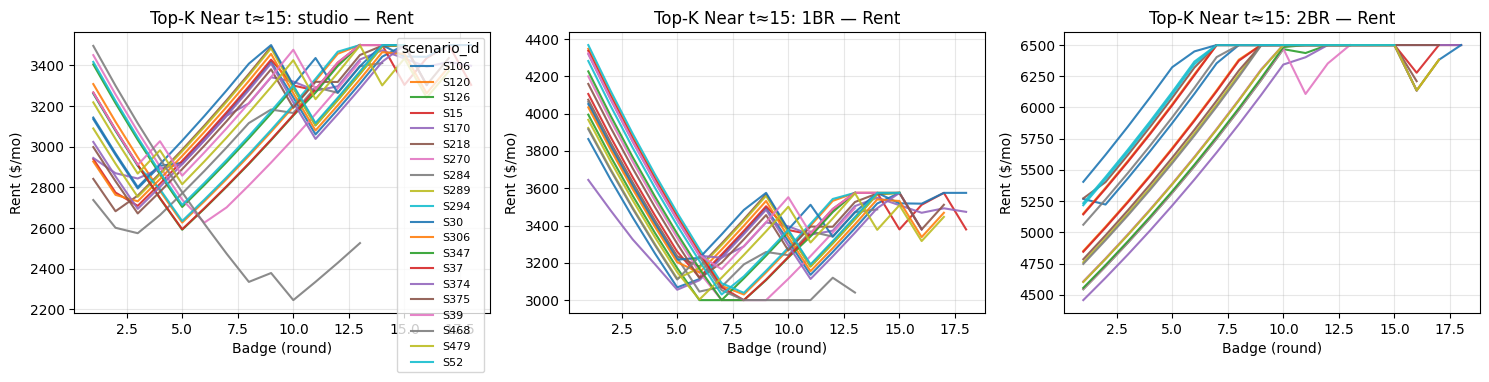

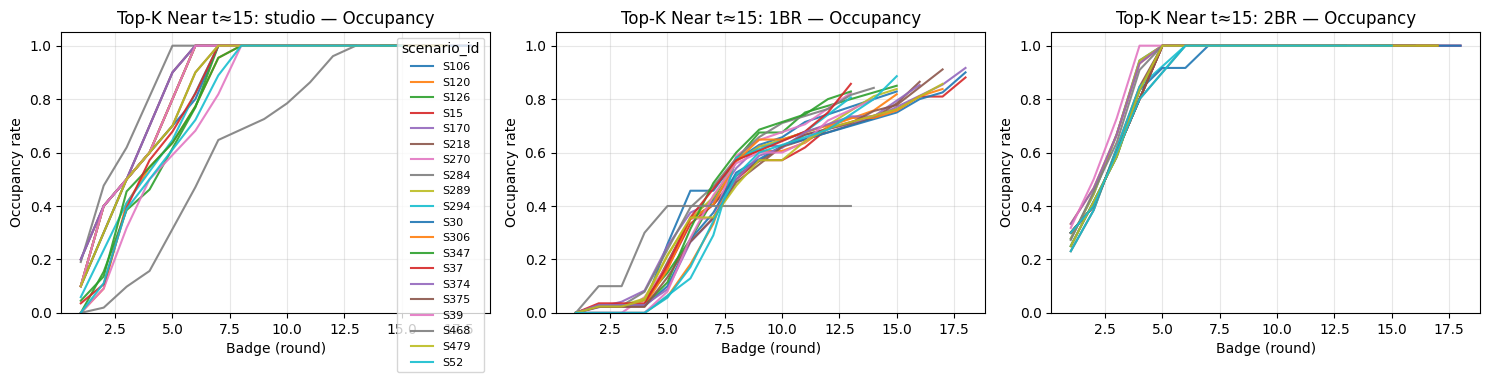

Top-K Near t≈15 — Final badge summary:


,scenario_id,unit_type,final_rent,final_occ_rate
0,S106,studio,3500.000000,1.000000
1,S106,1BR,3575.000000,0.828571
2,S106,2BR,6500.000000,1.000000
3,S120,studio,3500.000000,1.000000
4,S120,1BR,3575.000000,0.818182
5,S120,2BR,6500.000000,1.000000
6,S126,studio,3500.000000,1.000000
7,S126,1BR,3575.000000,0.850000
8,S126,2BR,6500.000000,1.000000
9,S15,studio,3304.000000,1.000000


In [15]:
# FINAL CELL — Top-K revenue / fastest / near-time (COMPLETED ONLY)
# Adds merged columns: occupied / total units -> "<type>_Units" (e.g., "2BR_Units": "5 / 100")
# PLUS: plots Top-K rent & occupancy paths (overlayed by scenario, faceted by unit_type).

import pandas as pd
import numpy as np
import os, glob
import matplotlib.pyplot as plt

# ===== User inputs =====
Vis_K = 20
K_REVENUE   = Vis_K
K_FASTEST   = Vis_K
AROUND_K    = Vis_K
TARGET_TIME = 15
OUT_DIR     = "out"
# =======================

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "agents"), exist_ok=True)

df = results_table.copy()

# --- Coerce booleans safely ---
def to_bool(s):
    if s.dtype == bool:
        return s
    return s.astype(str).str.strip().str.lower().isin({"true","t","yes","y","1"})

for c in ["completed","hit_limit"]:
    if c in df.columns:
        df[c] = to_bool(df[c])
    else:
        df[c] = False

mask = df["completed"] & (~df["hit_limit"])
if "max_batches" in globals():
    mask &= (df["time_to_fill"] < max_batches)

completed_df = df.loc[mask].copy()

if completed_df.empty:
    print("No completed scenarios after filtering.")
else:
    # ---- Normalize numeric columns ----
    if "total_revenue" in completed_df:
        completed_df["total_revenue_k"] = (completed_df["total_revenue"] / 1000).round(2)
    if "final_occupancy" in completed_df:
        completed_df["final_occupancy"] = completed_df["final_occupancy"].astype(float).round(2)
    if "total_gfa_used" in completed_df:
        completed_df["total_gfa_used"]  = completed_df["total_gfa_used"].astype(float).round(2)

    # ---- NEW: round sqft columns to 1 decimal place ----
    for c in [col for col in completed_df.columns if col.startswith("sqft_")]:
        completed_df[c] = completed_df[c].astype(float).round(1)


    # ---- derive offered total for one row+type (same logic you used earlier) ----
    def derive_total_units_row(row, typ):
        # 1) best: explicit units column if present
        cand = row.get(f"units_{typ}", np.nan)
        if pd.notna(cand):
            try:
                return int(cand)
            except Exception:
                pass

        # 2) from sqft totals if you have them
        st = row.get(f"sqft_total_{typ}", np.nan)
        sa = row.get(f"sqft_{typ}", np.nan)
        if pd.notna(st) and pd.notna(sa):
            try:
                sa_f = float(sa)
                if sa_f > 0:
                    return int(max(1, round(float(st) / sa_f)))
            except Exception:
                pass

        # 3) fallback: if completed, treat offered == occupied
        occ = row.get(f"occupied_{typ}", np.nan)
        comp = bool(row.get("completed", False))
        hitl = bool(row.get("hit_limit", False))
        ttf  = row.get("time_to_fill", np.inf)
        ok_t = True if "max_batches" not in globals() else (pd.notna(ttf) and ttf < max_batches)
        if comp and (not hitl) and ok_t and pd.notna(occ):
            return int(occ)

        return np.nan

    def attach_units_string(df_in, typ):
        occ_col = f"occupied_{typ}"
        out_col = f"{typ}_Units"

        if occ_col not in df_in.columns:
            return df_in

        # compute a clean total per row
        totals = []
        for _, r_ in df_in.iterrows():
            tot = derive_total_units_row(r_, typ)
            occ = r_.get(occ_col, np.nan)
            # enforce total >= occupied to avoid "5 / 2"
            if pd.notna(occ) and pd.notna(tot):
                tot = max(int(tot), int(occ))
            totals.append(tot)

        df_in = df_in.copy()
        df_in[f"__total_{typ}"] = totals
        df_in[out_col] = df_in.apply(
            lambda r: (f"{int(r[occ_col])} / {int(r[f'__total_{typ}'])}"
                    if pd.notna(r[occ_col]) and pd.notna(r[f"__total_{typ}"])
                    else np.nan),
            axis=1
        )
        df_in.drop(columns=[f"__total_{typ}"], inplace=True)
        return df_in

    for t in ["studio", "1BR", "2BR", "3BR"]:
        completed_df = attach_units_string(completed_df, t)
    
    # ---- Recompute total_units as SUM of offered denominators across types ----
    TYPES = ["studio", "1BR", "2BR", "3BR"]  # extend if you have 3BR, etc.

    # Build per-type offered totals (and ensure offered >= occupied)
    for typ in TYPES:
        occ_col = f"occupied_{typ}"
        # derive offered per row
        offered_vals = []
        for _, r_ in completed_df.iterrows():
            off = derive_total_units_row(r_, typ)
            occ = r_.get(occ_col, np.nan)
            if pd.notna(off) and pd.notna(occ):
                off = max(int(off), int(occ))  # never let offered < occupied
            offered_vals.append(off)
        # store a numeric column we can sum
        completed_df[f"units_{typ}"] = [int(v) if pd.notna(v) else 0 for v in offered_vals]

    # Now total_units = sum of offered per-type (not occupied!)
    offered_cols = [f"units_{t}" for t in TYPES]
    completed_df["total_units"] = completed_df[offered_cols].sum(axis=1).astype(int)

    # Optional: keep final_occupancy consistent with this denominator
    if "final_occupancy" in completed_df.columns:
        occ_cols = [c for c in completed_df.columns if c.startswith("occupied_")]
        with np.errstate(divide='ignore', invalid='ignore'):
            occ_sum = completed_df[occ_cols].sum(axis=1)
            den = completed_df["total_units"].replace(0, np.nan)
            completed_df["final_occupancy"] = (occ_sum / den).clip(upper=1).fillna(completed_df["final_occupancy"])



    # ---- Columns to keep ----
    keep_cols = [
        "scenario_id","time_to_fill","total_revenue_k","final_occupancy",
        "avg_rent_studio","studio_Units","sqft_studio",
        "avg_rent_1BR","1BR_Units","sqft_1BR",
        "avg_rent_2BR","2BR_Units","sqft_2BR",
        "avg_rent_3BR","3BR_Units","sqft_3BR",
        "total_units","total_gfa_used"
    ]
    keep_cols = [c for c in keep_cols if c in completed_df.columns]

    def clean(df_in):
        out = df_in[keep_cols].copy()
        return out.reset_index(drop=True)

    # ---------- Top-K by revenue ----------
    topk_revenue = (
        completed_df.sort_values(by=["total_revenue", "time_to_fill"], ascending=[False, True])
        .head(K_REVENUE)
    )
    topk_revenue = clean(topk_revenue)
    print(f"Top-{K_REVENUE} by revenue (COMPLETED ONLY):")
    display(topk_revenue)

    # ---------- Top-K by fastest ----------
    topk_fastest = (
        completed_df.sort_values(by=["time_to_fill", "total_revenue"], ascending=[True, False])
        .head(K_FASTEST)
    )
    topk_fastest = clean(topk_fastest)
    print(f"Top-{K_FASTEST} fastest to fill (COMPLETED ONLY):")
    display(topk_fastest)

    # ---------- Best revenue near target time ----------
    around = (
        completed_df
        .assign(_gap=(completed_df["time_to_fill"] - TARGET_TIME).abs())
        .sort_values(by=["_gap","total_revenue"], ascending=[True,False])
        .drop(columns="_gap")
        .head(AROUND_K)
    )
    around = clean(around)
    print(f"Highest revenue near time_to_fill ≈ {TARGET_TIME} (COMPLETED ONLY):")
    display(around)

    # ---------- Save CSVs ----------
    f_rev = os.path.join(OUT_DIR, "topk_revenue_completed.csv")
    f_fast = os.path.join(OUT_DIR, "topk_fastest_completed.csv")
    f_near = os.path.join(OUT_DIR, f"topk_near_time_{TARGET_TIME}_completed.csv")
    topk_revenue.to_csv(f_rev, index=False)
    topk_fastest.to_csv(f_fast, index=False)
    around.to_csv(f_near, index=False)

    # ---------- AGENT EXPORTS ----------
    acc_map = {r["scenario_id"]: r.get("accepted_df", pd.DataFrame()) for r in all_results}

    def collect_agents(sel_df):
        frames = []
        for _, row in sel_df.iterrows():
            sid = row["scenario_id"]
            adf = acc_map.get(sid, pd.DataFrame())
            if adf is not None and not adf.empty:
                adf = adf.copy()
                adf["scenario_id"] = sid
                cols = ["scenario_id"] + [c for c in adf.columns if c != "scenario_id"]
                adf = adf[cols]
                frames.append(adf)
                adf.to_csv(os.path.join(OUT_DIR, "agents", f"agents_{sid}.csv"), index=False)
        return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

    agents_revenue = collect_agents(topk_revenue)
    agents_fastest = collect_agents(topk_fastest)
    agents_around  = collect_agents(around)

    agents_revenue.to_csv(os.path.join(OUT_DIR, "agents_topk_revenue.csv"), index=False)
    agents_fastest.to_csv(os.path.join(OUT_DIR, "agents_topk_fastest.csv"), index=False)
    agents_around.to_csv(os.path.join(OUT_DIR, f"agents_topk_near_time_{TARGET_TIME}.csv"), index=False)

    print("CSVs saved in /out:")
    print(" -", f_rev)
    print(" -", f_fast)
    print(" -", f_near)
    print(" - agents_topk_revenue.csv / agents_topk_fastest.csv / agents_topk_near_time_{TARGET_TIME}.csv")
    print(" - individual scenario agents in /out/agents/")

    # ===================== NEW: Top-K MULTI-SCENARIO PLOTS =====================
    # If all VIS_PLOT_* flags are False, no plots will be produced below.

    # Build a quick index for in-memory results
    res_by_id = {r.get("scenario_id", f"NA_{i}"): r for i, r in enumerate(all_results)}

    def load_badge_log_for_scenario_id(sid):
        """Try in-memory badge_log, else CSV in logs/, else reconstruct from rent_history."""
        r = res_by_id.get(sid)
        # 1) in-memory
        if isinstance(r, dict) and "badge_log" in r and isinstance(r["badge_log"], pd.DataFrame):
            dfb = r["badge_log"].copy()
            dfb["scenario_id"] = sid
            return dfb
        # 2) saved CSV
        cand = f"logs/scenario_{sid}_badges.csv"
        if os.path.exists(cand):
            dfb = pd.read_csv(cand)
            dfb["scenario_id"] = sid
            return dfb
        # 3) reconstruct from rent_history + occupancy_history
        if isinstance(r, dict) and ("rent_history" in r or "occupancy_history" in r):
            rent_hist = r.get("rent_history", [])
            occ_hist  = r.get("occupancy_history", [])
            rows = []
            for i, d in enumerate(rent_hist, start=1):
                for u, rent in d.items():
                    rows.append({
                        "scenario_id": sid,
                        "badge": i,
                        "unit_type": u,
                        "rent": rent,
                        "assigned": np.nan,
                        "capacity": np.nan,
                        "occupancy_rate": np.nan
                    })
            dfb = pd.DataFrame(rows) if rows else None
            if dfb is not None and len(occ_hist) == dfb["badge"].max():
                overall = pd.DataFrame({"badge": np.arange(1, len(occ_hist)+1), "occ_total": occ_hist})
                dfb = dfb.merge(overall, on="badge", how="left")
            return dfb
        return None

    def plot_topk_set(name, sel_df):
        """Overlay rent/occupancy paths for a selected Top-K set (DataFrame with scenario_id)."""
        if sel_df is None or sel_df.empty:
            print(f"({name}) Nothing to plot.")
            return

        # Load logs for all scenarios in this set
        frames, missing = [], []
        for sid in sel_df["scenario_id"].tolist():
            dfi = load_badge_log_for_scenario_id(sid)
            if dfi is None or dfi.empty:
                missing.append(sid)
                continue
            frames.append(dfi)

        if not frames:
            print(f"({name}) Could not load any badge logs. Missing:", missing)
            return

        df_all = pd.concat(frames, ignore_index=True)

        # Compute occupancy_rate if possible
        if ("occupancy_rate" not in df_all.columns or df_all["occupancy_rate"].isna().all()) and \
           ("assigned" in df_all.columns and "capacity" in df_all.columns):
            with np.errstate(divide='ignore', invalid='ignore'):
                df_all["occupancy_rate"] = df_all["assigned"] / df_all["capacity"]

        # Order unit types nicely if present
        order_guess = ["Studio","studio","0BR","1BR","2BR","3BR"]
        present = [x for x in order_guess if x in df_all["unit_type"].unique().tolist()]
        if present:
            df_all["unit_type"] = pd.Categorical(df_all["unit_type"], categories=present, ordered=True)
            df_all = df_all.sort_values(["unit_type","badge","scenario_id"])

        unit_types = df_all["unit_type"].dropna().unique().tolist()
        n = len(unit_types)
        cols = min(3, n) if n > 0 else 1
        rows = int(np.ceil(n / cols)) if n > 0 else 1

        # ---- Plot: Rent paths (faceted) ----
        plt.figure(figsize=(5*cols, 3.8*rows))
        for i, ut in enumerate(unit_types, start=1):
            ax = plt.subplot(rows, cols, i)
            sub = df_all[df_all["unit_type"]==ut]
            for sid, g in sub.groupby("scenario_id"):
                ax.plot(g["badge"], g["rent"], label=str(sid), alpha=0.9)
            ax.set_title(f"{name}: {ut} — Rent")
            ax.set_xlabel("Badge (round)")
            ax.set_ylabel("Rent ($/mo)")
            ax.grid(alpha=0.3)
            if i == 1:
                ax.legend(title="scenario_id", fontsize=8)
        plt.tight_layout()
        plt.show()

        # ---- Plot: Occupancy paths (faceted) ----
        has_per_type_occ = "occupancy_rate" in df_all.columns and df_all["occupancy_rate"].notna().any()
        if has_per_type_occ:
            plt.figure(figsize=(5*cols, 3.8*rows))
            for i, ut in enumerate(unit_types, start=1):
                ax = plt.subplot(rows, cols, i)
                sub = df_all[df_all["unit_type"]==ut]
                for sid, g in sub.groupby("scenario_id"):
                    ax.plot(g["badge"], g["occupancy_rate"], label=str(sid), alpha=0.9)
                ax.set_title(f"{name}: {ut} — Occupancy")
                ax.set_xlabel("Badge (round)")
                ax.set_ylabel("Occupancy rate")
                ax.set_ylim(0, 1.05)
                ax.grid(alpha=0.3)
                if i == 1:
                    ax.legend(title="scenario_id", fontsize=8)
            plt.tight_layout()
            plt.show()
        elif "occ_total" in df_all.columns:
            # Overall occupancy fallback
            plt.figure(figsize=(7.5,4.5))
            for sid, g in (df_all.drop_duplicates(["scenario_id","badge"])
                                 .sort_values(["scenario_id","badge"])
                                 .groupby("scenario_id")):
                plt.plot(g["badge"], g["occ_total"], label=str(sid), alpha=0.9)
            plt.title(f"{name}: Overall occupancy (building)")
            plt.xlabel("Badge (round)")
            plt.ylabel("Occupancy rate")
            plt.ylim(0, 1.05)
            plt.grid(alpha=0.3)
            plt.legend(title="scenario_id")
            plt.tight_layout()
            plt.show()

        # ---- Summary at final badge per scenario ----
        final_badge_by_sid = df_all.groupby("scenario_id")["badge"].max()
        summaries = []
        for sid, bmax in final_badge_by_sid.items():
            g = df_all[(df_all["scenario_id"]==sid) & (df_all["badge"]==bmax)]
            s = (g.groupby("unit_type")
                  .agg(final_rent=("rent","mean"),
                       final_occ_rate=("occupancy_rate","mean"))
                  .reset_index())
            s.insert(0, "scenario_id", sid)
            summaries.append(s)
        if summaries:
            summary_topk = pd.concat(summaries, ignore_index=True)
            print(f"{name} — Final badge summary:")
            display(summary_topk)

    # ---- Plot all three Top-K sets ----
    if VIS_PLOT_REVENUE:
        plot_topk_set("Top-K Revenue", topk_revenue)
    if VIS_PLOT_FASTEST:
        plot_topk_set("Top-K Fastest", topk_fastest)
    if VIS_PLOT_NEAR:
        plot_topk_set(f"Top-K Near t≈{TARGET_TIME}", around)


**I: Overall View**

--- around_target_15 ---


,mean,std
time_to_fill,14.35000,3.048295
total_revenue_k,2406.44100,450.707180
final_occupancy,0.91759,0.014340


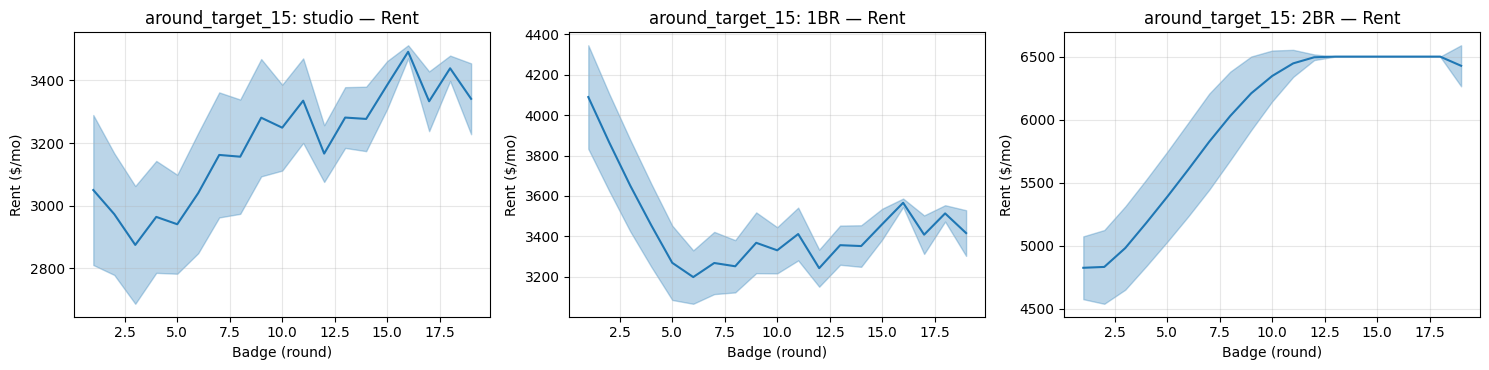

Saved: out/overall_around_target_15_badge_bands.png


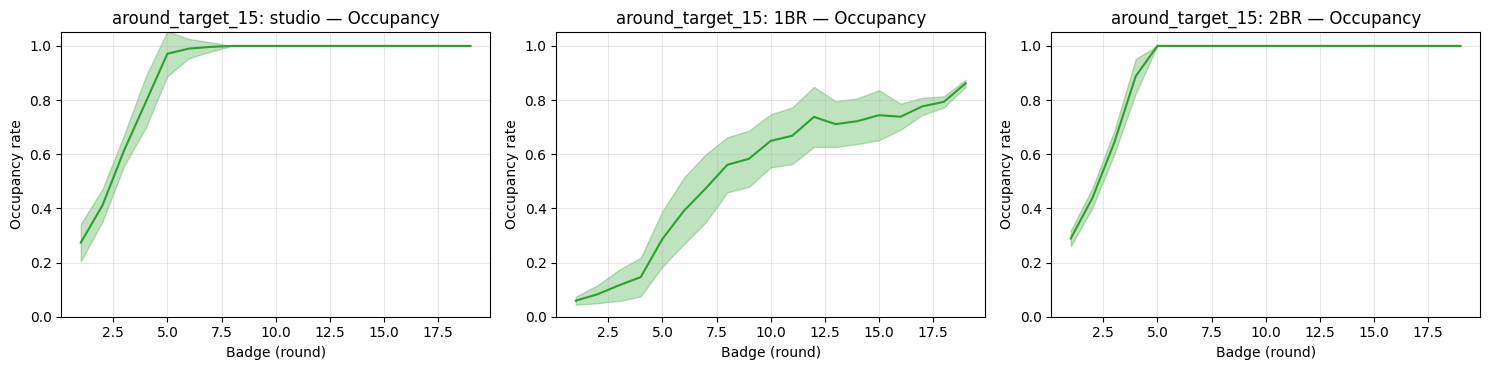

Saved: out/overall_around_target_15_occupancy_bands.png


In [21]:
# I: Overall View — category summary and mean±std badge plots (same layout as cell G)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    _ = topk_revenue
    _ = topk_fastest
    _ = around
except NameError:
    print("Top-K sets not defined (no completed scenarios). Skipping Overall View.")
else:
    res_by_id = {r.get("scenario_id", r.get("id", "?")): r for r in all_results}

    def load_badge_log_for_scenario_id(sid):
        r = res_by_id.get(sid)
        if isinstance(r, dict) and "badge_log" in r and isinstance(r["badge_log"], pd.DataFrame):
            dfb = r["badge_log"].copy()
            dfb["scenario_id"] = sid
            return dfb
        cand = f"logs/scenario_{sid}_badges.csv"
        if os.path.exists(cand):
            dfb = pd.read_csv(cand)
            dfb["scenario_id"] = sid
            return dfb
        if isinstance(r, dict) and ("rent_history" in r or "occupancy_history" in r):
            rent_hist = r.get("rent_history", [])
            occ_hist = r.get("occupancy_history", [])
            rows = []
            for i, d in enumerate(rent_hist, start=1):
                for u, rent in d.items():
                    rows.append({"scenario_id": sid, "badge": i, "unit_type": u, "rent": rent,
                                 "assigned": np.nan, "capacity": np.nan, "occupancy_rate": np.nan})
            dfb = pd.DataFrame(rows) if rows else None
            if dfb is not None and len(occ_hist) == dfb["badge"].max():
                overall = pd.DataFrame({"badge": np.arange(1, len(occ_hist) + 1), "occ_total": occ_hist})
                dfb = dfb.merge(overall, on="badge", how="left")
            return dfb
        return None

    def category_metric_summary(sel_df):
        num_cols = ["time_to_fill", "total_revenue", "total_revenue_k", "final_occupancy"]
        num_cols = [c for c in num_cols if c in sel_df.columns]
        if not num_cols:
            return pd.DataFrame()
        return sel_df[num_cols].agg(["mean", "std"]).T

    def build_category_badge_long(sel_df):
        if "scenario_id" not in sel_df.columns:
            return pd.DataFrame()
        rows = []
        for sid in sel_df["scenario_id"].dropna().unique():
            dfi = load_badge_log_for_scenario_id(sid)
            if dfi is not None and not dfi.empty:
                dfi = dfi.copy()
                dfi["scenario_id"] = sid
                rows.append(dfi)
        return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

    def summarize_badge_paths(df_long):
        if df_long.empty or "badge" not in df_long.columns:
            return pd.DataFrame()
        if "unit_type" in df_long.columns and df_long["unit_type"].notna().any():
            g = df_long.groupby(["badge", "unit_type"])
        else:
            g = df_long.groupby("badge")
        out = g.agg(mean=("rent", "mean"), std=("rent", "std")).reset_index()
        return out

    def plot_overall_like_g(name, df_long):
        if df_long.empty or "badge" not in df_long.columns:
            return None
        df = df_long.copy()
        if "unit_type" in df.columns and df["unit_type"].notna().any():
            order_guess = ["Studio", "studio", "0BR", "1BR", "2BR", "3BR"]
            present = [x for x in order_guess if x in df["unit_type"].unique().tolist()]
            if present:
                df["unit_type"] = pd.Categorical(df["unit_type"], categories=present, ordered=True)
                df = df.sort_values(["unit_type", "badge", "scenario_id"])
            unit_types = df["unit_type"].dropna().unique().tolist()
        else:
            unit_types = ["(all)"]
            df["unit_type"] = "(all)"
        n = len(unit_types)
        cols = min(3, n) if n > 0 else 1
        rows = int(np.ceil(n / cols)) if n > 0 else 1
        summary = summarize_badge_paths(df)

        # ---- Rent: one subplot per unit type (same layout as G) ----
        fig = plt.figure(figsize=(5 * cols, 3.8 * rows))
        for i, ut in enumerate(unit_types, start=1):
            ax = plt.subplot(rows, cols, i)
            if "unit_type" in summary.columns:
                sub = summary[summary["unit_type"] == ut]
            else:
                sub = summary
            if sub.empty:
                ax.set_title(f"{name}: {ut} — Rent")
                continue
            x = sub["badge"].values
            mean = sub["mean"].values
            std = sub["std"].fillna(0).values
            ax.plot(x, mean, color="tab:blue", label="mean")
            ax.fill_between(x, mean - std, mean + std, alpha=0.3, color="tab:blue")
            ax.set_title(f"{name}: {ut} — Rent")
            ax.set_xlabel("Badge (round)")
            ax.set_ylabel("Rent ($/mo)")
            ax.grid(alpha=0.3)
        plt.tight_layout()
        return fig

    def plot_overall_occupancy_like_g(name, df_long):
        if df_long.empty or "occupancy_rate" not in df_long.columns or not df_long["occupancy_rate"].notna().any():
            return None
        df = df_long.copy()
        if "unit_type" in df.columns and df["unit_type"].notna().any():
            order_guess = ["Studio", "studio", "0BR", "1BR", "2BR", "3BR"]
            present = [x for x in order_guess if x in df["unit_type"].unique().tolist()]
            if present:
                df["unit_type"] = pd.Categorical(df["unit_type"], categories=present, ordered=True)
                df = df.sort_values(["unit_type", "badge", "scenario_id"])
            unit_types = df["unit_type"].dropna().unique().tolist()
        else:
            unit_types = ["(all)"]
            df["unit_type"] = "(all)"
        n = len(unit_types)
        cols = min(3, n) if n > 0 else 1
        rows = int(np.ceil(n / cols)) if n > 0 else 1
        if "unit_type" in df.columns:
            occ_summary = df.groupby(["badge", "unit_type"])["occupancy_rate"].agg(["mean", "std"]).reset_index()
        else:
            occ_summary = df.groupby("badge")["occupancy_rate"].agg(["mean", "std"]).reset_index()
            occ_summary["unit_type"] = "(all)"

        fig = plt.figure(figsize=(5 * cols, 3.8 * rows))
        for i, ut in enumerate(unit_types, start=1):
            ax = plt.subplot(rows, cols, i)
            if "unit_type" in occ_summary.columns:
                sub = occ_summary[occ_summary["unit_type"] == ut]
            else:
                sub = occ_summary
            if sub.empty:
                ax.set_title(f"{name}: {ut} — Occupancy")
                continue
            x = sub["badge"].values
            mean = sub["mean"].values
            std = sub["std"].fillna(0).values
            ax.plot(x, mean, color="tab:green", label="mean")
            ax.fill_between(x, mean - std, mean + std, alpha=0.3, color="tab:green")
            ax.set_title(f"{name}: {ut} — Occupancy")
            ax.set_xlabel("Badge (round)")
            ax.set_ylabel("Occupancy rate")
            ax.set_ylim(0, 1.05)
            ax.grid(alpha=0.3)
        plt.tight_layout()
        return fig

    def _safe_name(name):
        import re
        return re.sub(r"[^a-zA-Z0-9_-]", "_", str(name))

    # Only process sets that are enabled in CONFIG (same as cell G)
    items = []
    if VIS_PLOT_REVENUE:
        items.append(("topk_revenue", topk_revenue))
    if VIS_PLOT_FASTEST:
        items.append(("topk_fastest", topk_fastest))
    if VIS_PLOT_NEAR:
        items.append((f"around_target_{TARGET_TIME}", around))
    for set_name, sel_df in items:
        if sel_df is None or sel_df.empty:
            continue
        tbl = category_metric_summary(sel_df)
        if not tbl.empty:
            print(f"--- {set_name} ---")
            display(tbl)
        df_long = build_category_badge_long(sel_df)
        if df_long.empty:
            continue
        fig = plot_overall_like_g(set_name, df_long)
        if fig is not None:
            out_path = os.path.join(OUT_DIR, f"overall_{_safe_name(set_name)}_badge_bands.png")
            fig.savefig(out_path, dpi=120, bbox_inches="tight")
            plt.show(fig)
            plt.close(fig)
            print(f"Saved: {out_path}")
        fig_occ = plot_overall_occupancy_like_g(set_name, df_long)
        if fig_occ is not None:
            out_path_occ = os.path.join(OUT_DIR, f"overall_{_safe_name(set_name)}_occupancy_bands.png")
            fig_occ.savefig(out_path_occ, dpi=120, bbox_inches="tight")
            plt.show(fig_occ)
            plt.close(fig_occ)
            print(f"Saved: {out_path_occ}")

**J: Animated GIFs**

When `VIS_PLOT_GIF` is True, produces animated GIFs for each enabled Top-K set: **selected scenarios** (G-style, one line per scenario) and **overview** (I-style, mean±std bands) for both rent and occupancy.


In [29]:
# J: Animated GIFs (rent & occupancy, G-style and I-style) — only if VIS_PLOT_GIF
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if not VIS_PLOT_GIF:
    print("VIS_PLOT_GIF is False. Set to True in CONFIG to produce GIFs.")
else:
    try:
        _ = topk_revenue
        _ = topk_fastest
        _ = around
    except NameError:
        print("Top-K sets not defined. Run cell G and I first.")
    else:
        try:
            from matplotlib.animation import FuncAnimation, PillowWriter
        except ImportError:
            from matplotlib.animation import FuncAnimation
            PillowWriter = None
        if PillowWriter is None:
            try:
                from matplotlib.animation import PillowWriter
            except ImportError:
                PillowWriter = None
        if PillowWriter is None:
            print("Install Pillow (pip install Pillow) to save GIFs.")
        else:
            res_by_id = {r.get("scenario_id", r.get("id", "?")): r for r in all_results}

            def load_badge_log_for_scenario_id(sid):
                r = res_by_id.get(sid)
                if isinstance(r, dict) and "badge_log" in r and isinstance(r["badge_log"], pd.DataFrame):
                    dfb = r["badge_log"].copy()
                    dfb["scenario_id"] = sid
                    return dfb
                cand = f"logs/scenario_{sid}_badges.csv"
                if os.path.exists(cand):
                    dfb = pd.read_csv(cand)
                    dfb["scenario_id"] = sid
                    return dfb
                if isinstance(r, dict) and ("rent_history" in r or "occupancy_history" in r):
                    rent_hist = r.get("rent_history", [])
                    occ_hist = r.get("occupancy_history", [])
                    rows = []
                    for i, d in enumerate(rent_hist, start=1):
                        for u, rent in d.items():
                            rows.append({"scenario_id": sid, "badge": i, "unit_type": u, "rent": rent,
                                         "assigned": np.nan, "capacity": np.nan, "occupancy_rate": np.nan})
                    dfb = pd.DataFrame(rows) if rows else None
                    if dfb is not None and len(occ_hist) == dfb["badge"].max():
                        overall = pd.DataFrame({"badge": np.arange(1, len(occ_hist) + 1), "occ_total": occ_hist})
                        dfb = dfb.merge(overall, on="badge", how="left")
                    return dfb
                return None

            def build_category_badge_long(sel_df):
                if "scenario_id" not in sel_df.columns:
                    return pd.DataFrame()
                rows = []
                for sid in sel_df["scenario_id"].dropna().unique():
                    dfi = load_badge_log_for_scenario_id(sid)
                    if dfi is not None and not dfi.empty:
                        dfi = dfi.copy()
                        dfi["scenario_id"] = sid
                        rows.append(dfi)
                return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

            def _safe_name(name):
                import re
                return re.sub(r"[^a-zA-Z0-9_-]", "_", str(name))

            # Same enabled sets as cell I
            items = []
            if VIS_PLOT_REVENUE:
                items.append(("topk_revenue", topk_revenue))
            if VIS_PLOT_FASTEST:
                items.append(("topk_fastest", topk_fastest))
            if VIS_PLOT_NEAR:
                items.append((f"around_target_{TARGET_TIME}", around))

            GIF_FPS = 5

            for set_name, sel_df in items:
                if sel_df is None or sel_df.empty:
                    continue
                df_long = build_category_badge_long(sel_df)
                if df_long.empty:
                    continue
                df = df_long.copy()
                if "unit_type" not in df.columns or not df["unit_type"].notna().any():
                    df["unit_type"] = "(all)"
                order_guess = ["Studio", "studio", "0BR", "1BR", "2BR", "3BR"]
                present = [x for x in order_guess if x in df["unit_type"].unique().tolist()]
                if present:
                    df["unit_type"] = pd.Categorical(df["unit_type"], categories=present, ordered=True)
                    df = df.sort_values(["unit_type", "badge", "scenario_id"])
                unit_types = df["unit_type"].dropna().unique().tolist()
                n_ut = len(unit_types)
                cols = min(3, n_ut) if n_ut else 1
                rows = int(np.ceil(n_ut / cols)) if n_ut else 1
                badges = sorted(df["badge"].dropna().unique().astype(int).tolist())
                if not badges:
                    continue
                n_badges = len(badges)
                frame_badges = badges

                # ---- G-style: selected scenarios (one line per scenario) ----
                for ycol, label, fname_suffix in [("rent", "Rent", "rent_scenarios"), ("occupancy_rate", "Occupancy", "occ_scenarios")]:
                    if ycol not in df.columns or (ycol == "occupancy_rate" and not df[ycol].notna().any()):
                        continue
                    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.8 * rows))
                    if n_ut == 1:
                        axes = np.array([axes])
                    axes = axes.flatten()
                    lines_by_ax = []
                    for i, ut in enumerate(unit_types):
                        ax = axes[i]
                        sub = df[df["unit_type"] == ut]
                        scens = sub["scenario_id"].unique().tolist()
                        for sid in scens:
                            g = sub[sub["scenario_id"] == sid].sort_values("badge")
                            ln, = ax.plot([], [], label=str(sid), alpha=0.9)
                            lines_by_ax.append((ax, ln, g["badge"].values, g[ycol].values))
                    for j in range(n_ut, len(axes)):
                        axes[j].set_visible(False)

                    def init_g():
                        for ax, ln, x, y in lines_by_ax:
                            ln.set_data([], [])
                        return [ln for _, ln, _, _ in lines_by_ax]

                    def animate_g(frame_idx):
                        t = frame_badges[frame_idx] if frame_idx < len(frame_badges) else frame_badges[-1]
                        for ax, ln, x, y in lines_by_ax:
                            mask = x <= t
                            ln.set_data(x[mask], y[mask])
                        return [ln for _, ln, _, _ in lines_by_ax]

                    for i, ax in enumerate(axes[:n_ut]):
                        ax.set_xlim(0, max(badges) * 1.02)
                        if ycol == "occupancy_rate":
                            ax.set_ylim(0, 1.05)
                        else:
                            # Explicit y limits so blit=True shows rent (autoscale is not redrawn with blit)
                            ut_vals = df[df["unit_type"] == unit_types[i]][ycol].dropna()
                            if len(ut_vals):
                                lo, hi = float(ut_vals.min()), float(ut_vals.max())
                                pad = (hi - lo) * 0.05 if hi > lo else 1
                                ax.set_ylim(lo - pad, hi + pad)
                            else:
                                ax.set_ylim(0, 1)
                        ax.set_xlabel("Badge (round)")
                        ax.set_ylabel("Rent ($/mo)" if ycol == "rent" else "Occupancy rate")
                        ax.grid(alpha=0.3)
                    for i, ut in enumerate(unit_types):
                        axes[i].set_title(f"{set_name}: {ut} — {label}")
                    if lines_by_ax:
                        axes[0].legend(title="scenario_id", fontsize=8)
                    plt.tight_layout()
                    anim = FuncAnimation(fig, animate_g, init_func=init_g, frames=len(frame_badges), interval=1000//GIF_FPS, blit=True)
                    out_path = os.path.join(OUT_DIR, f"gif_{_safe_name(set_name)}_{fname_suffix}.gif")
                    anim.save(out_path, writer=PillowWriter(fps=GIF_FPS))
                    plt.close(fig)
                    print(f"Saved: {out_path}")

                # ---- I-style: overview (mean ± std bands) ----
                for ycol, label, fname_suffix in [("rent", "Rent", "rent_overview"), ("occupancy_rate", "Occupancy", "occ_overview")]:
                    if ycol not in df.columns or (ycol == "occupancy_rate" and not df[ycol].notna().any()):
                        continue
                    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.8 * rows))
                    if n_ut == 1:
                        axes = np.array([axes])
                    axes = axes.flatten()
                    band_artists = []
                    for i, ut in enumerate(unit_types):
                        sub = df[df["unit_type"] == ut]
                        summ = sub.groupby("badge")[ycol].agg(["mean", "std"]).reset_index()
                        summ["std"] = summ["std"].fillna(0)
                        band_artists.append((axes[i], summ))

                    def init_i():
                        for ax, summ in band_artists:
                            ax.clear()
                        return []

                    def animate_i(frame_idx):
                        t = frame_badges[frame_idx] if frame_idx < len(frame_badges) else frame_badges[-1]
                        for ax, summ in band_artists:
                            ax.clear()
                            s = summ[summ["badge"] <= t]
                            if not s.empty:
                                x, m, std = s["badge"].values, s["mean"].values, s["std"].values
                                ax.plot(x, m, color="tab:blue" if ycol == "rent" else "tab:green", label="mean")
                                ax.fill_between(x, m - std, m + std, alpha=0.3, color="tab:blue" if ycol == "rent" else "tab:green")
                            ax.set_xlim(0, max(badges) * 1.02)
                            if ycol == "occupancy_rate":
                                ax.set_ylim(0, 1.05)
                            ax.set_xlabel("Badge (round)")
                            ax.set_ylabel("Rent ($/mo)" if ycol == "rent" else "Occupancy rate")
                            ax.grid(alpha=0.3)
                        for i, ut in enumerate(unit_types):
                            axes[i].set_title(f"{set_name}: {ut} — {label} (overview)")
                        return []

                    plt.tight_layout()
                    anim = FuncAnimation(fig, animate_i, init_func=init_i, frames=len(frame_badges), interval=1000//GIF_FPS, blit=False)
                    out_path = os.path.join(OUT_DIR, f"gif_{_safe_name(set_name)}_{fname_suffix}.gif")
                    anim.save(out_path, writer=PillowWriter(fps=GIF_FPS))
                    plt.close(fig)
                    print(f"Saved: {out_path}")

            print("GIFs written to OUT_DIR.")

Saved: /Users/tumenglun/Desktop/ABM/gif_around_target_15_rent_scenarios.gif
Saved: /Users/tumenglun/Desktop/ABM/gif_around_target_15_occ_scenarios.gif
Saved: /Users/tumenglun/Desktop/ABM/gif_around_target_15_rent_overview.gif
Saved: /Users/tumenglun/Desktop/ABM/gif_around_target_15_occ_overview.gif
GIFs written to OUT_DIR.
